In [1]:
# =============================================================================
# 05b_spatial_maps.ipynb — VERSIÓN REVISADA COMPLETA
# Banco Burdwood — Análisis espacial de estrés de pH
# =============================================================================
# Cambios respecto a la versión anterior:
#   1. % de área en estrés calculado solo dentro de BBI+BBII (no bbox)
#   2. Gráfico de evolución temporal corregido con máscara BBI+BBII
#   3. Mapas nuevos pre/post cambio de régimen (2005) con pH invernal
#   4. Solo dos períodos (sin transición), corte en enero 2006
#
# Corte pre/post régimen: enero 2006
#   Justificación: cubre ambos puntos de cambio (BBI: sep-2005, BBII: nov-2005)
#   y coincide con año calendario completo
# =============================================================================
 

#### Librerias y paths

In [2]:
# =============================================================================
# CELDA 1 — Librerías y paths
# =============================================================================
 
import os
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
from shapely.ops import unary_union
 
BASE_DIR      = os.path.abspath("..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed", "pH")
SHAPES_DIR    = os.path.join(BASE_DIR, "data", "raw", "shapes")
FIGURES_DIR   = os.path.join(BASE_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
 
# Períodos — corte en enero 2006 (después de ambos puntos CUSUM)
PERIOD_PRE  = (1985, 2005)
PERIOD_POST = (2006, 2024)
WINTER_MONTHS = [7, 8, 9]  # julio–septiembre (invierno austral)
 
print("Setup listo ✅")

Setup listo ✅


#### Cargar datos y shapes

In [3]:
# =============================================================================
# CELDA 2 — Cargar datos y shapes
# =============================================================================
 
# bbox para análisis espacial píxel a píxel
ds       = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_bbox_ready.nc"))
ph       = ds["ph"]
 
bbi_shape  = gpd.read_file(os.path.join(SHAPES_DIR, "transicion_solo.shp"))
bbii_shape = gpd.read_file(os.path.join(SHAPES_DIR, "BBII_unificado.shp"))
 
print(f"Dataset: {dict(ph.sizes)}")
print(f"Período: {str(ph.time.values[0])[:10]} → {str(ph.time.values[-1])[:10]}")

Dataset: {'time': 480, 'latitude': 14, 'longitude': 37}
Período: 1985-01-01 → 2024-12-01


#### Máscara BBI+BBII (para cálculos de % área)

In [4]:
# =============================================================================
# CELDA 3 — Máscara BBI+BBII (para cálculos de % área)
# =============================================================================
# Usamos intersects() con box de 0.25° para incluir píxeles en el borde
 
union_bbi  = bbi_shape.geometry.union_all()
union_bbii = bbii_shape.geometry.union_all()
bb_total   = unary_union([union_bbi, union_bbii])
 
lats = ph.latitude.values
lons = ph.longitude.values
LON, LAT = np.meshgrid(lons, lats)
 
res    = 0.25
pixels = [box(lo-res/2, la-res/2, lo+res/2, la+res/2)
          for lo, la in zip(LON.ravel(), LAT.ravel())]
inside = np.array([bb_total.intersects(p) for p in pixels]).reshape(LAT.shape)

print(f"Píxeles dentro de BBI+BBII: {inside.sum()} de {inside.size}")

 
# pH enmascarado — solo píxeles dentro de BBI+BBII
ph_bb = ph.where(inside)
 

 

Píxeles dentro de BBI+BBII: 168 de 518


#### Percentil 5 local (por píxel, sobre toda la serie)

In [5]:
# =============================================================================
# CELDA 4 — Percentil 5 local (por píxel, sobre toda la serie)
# =============================================================================
# El umbral se calcula sobre TODA la grilla bbox para que sea consistente
# con el análisis espacial. Para el % de área en estrés se aplica la
# máscara del BB después.
 
print("Calculando percentil 5 local...")
ph_p05 = ph.quantile(0.05, dim="time")
print(f"  rango: {float(ph_p05.min()):.4f} – {float(ph_p05.max()):.4f}")

Calculando percentil 5 local...
  rango: 8.0332 – 8.0432


#### Serie temporal del % de área en estrés (dentro de BBI+BBII)

In [6]:
# =============================================================================
# CELDA 5 — Serie temporal del % de área en estrés (dentro de BBI+BBII)
# =============================================================================
 
# Máscara de estrés sobre píxeles del BB
stress_mask_bb = ph_bb < ph_p05
 
# % de área en estrés por mes
n_stress = stress_mask_bb.sum(dim=["latitude", "longitude"])
n_valid  = (~ph_bb.isnull()).sum(dim=["latitude", "longitude"])
pct_stress = 100 * n_stress / n_valid
 
df_stress_ts = pct_stress.to_dataframe(name="pct_stress").reset_index()
df_stress_ts["time"]  = pd.to_datetime(df_stress_ts["time"])
df_stress_ts["year"]  = df_stress_ts["time"].dt.year
df_stress_ts["month"] = df_stress_ts["time"].dt.month
 
print(f"Primer mes con estrés: "
      f"{df_stress_ts[df_stress_ts['pct_stress']>0]['time'].min().strftime('%Y-%m')}")
print(f"Máx % área en estrés : {df_stress_ts['pct_stress'].max():.1f}%")

Primer mes con estrés: 2017-08
Máx % área en estrés : 100.0%


#### Gráfico de evolución temporal del área en estrés

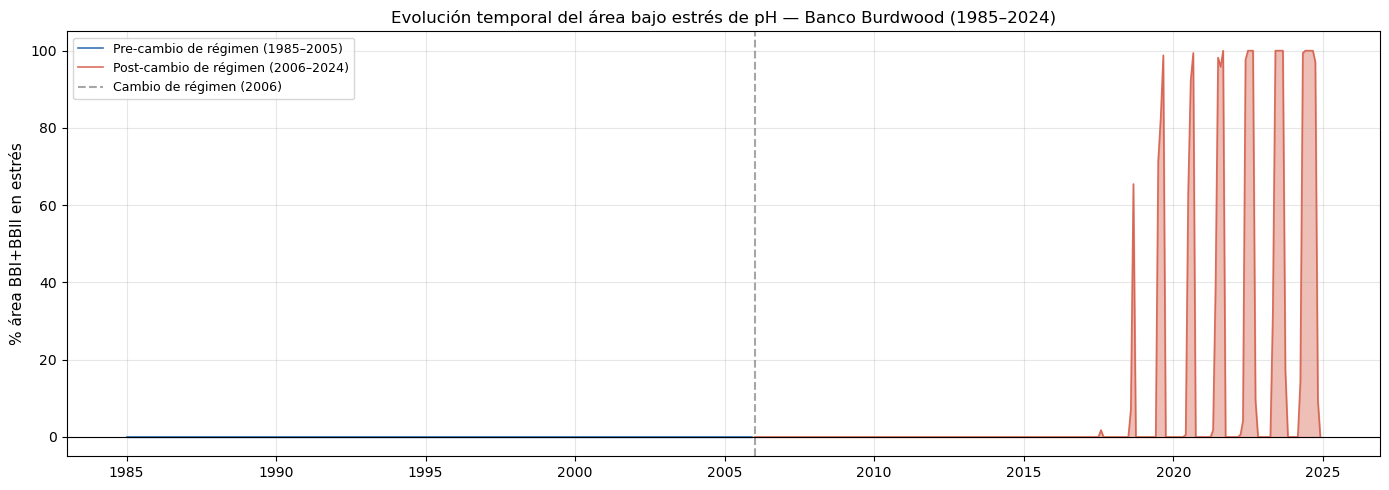

✅ stress_area_timeseries.png


In [7]:
# =============================================================================
# CELDA 6 — Gráfico de evolución temporal del área en estrés
# =============================================================================
 
fig, ax = plt.subplots(figsize=(14, 5))
 
# Colorear por período
for y1, y2, color, label in [
    (1985, 2005, "#2166ac", "Pre-cambio de régimen (1985–2005)"),
    (2006, 2024, "#d6604d", "Post-cambio de régimen (2006–2024)"),
]:
    mask = (df_stress_ts["year"] >= y1) & (df_stress_ts["year"] <= y2)
    ax.fill_between(df_stress_ts.loc[mask, "time"],
                    df_stress_ts.loc[mask, "pct_stress"],
                    alpha=0.4, color=color)
    ax.plot(df_stress_ts.loc[mask, "time"],
            df_stress_ts.loc[mask, "pct_stress"],
            color=color, lw=1.2, alpha=0.9, label=label)
 
ax.axvline(pd.Timestamp("2006-01-01"), color="gray",
           lw=1.5, linestyle="--", alpha=0.7, label="Cambio de régimen (2006)")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("% área BBI+BBII en estrés", fontsize=11)
ax.set_title("Evolución temporal del área bajo estrés de pH — Banco Burdwood (1985–2024)",
             fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stress_area_timeseries.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ stress_area_timeseries.png")

#### Mapas de % de meses en estrés por período (P1 y P2)

C:\Users\gisel\AppData\Local\Temp\ipykernel_97880\1352258891.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


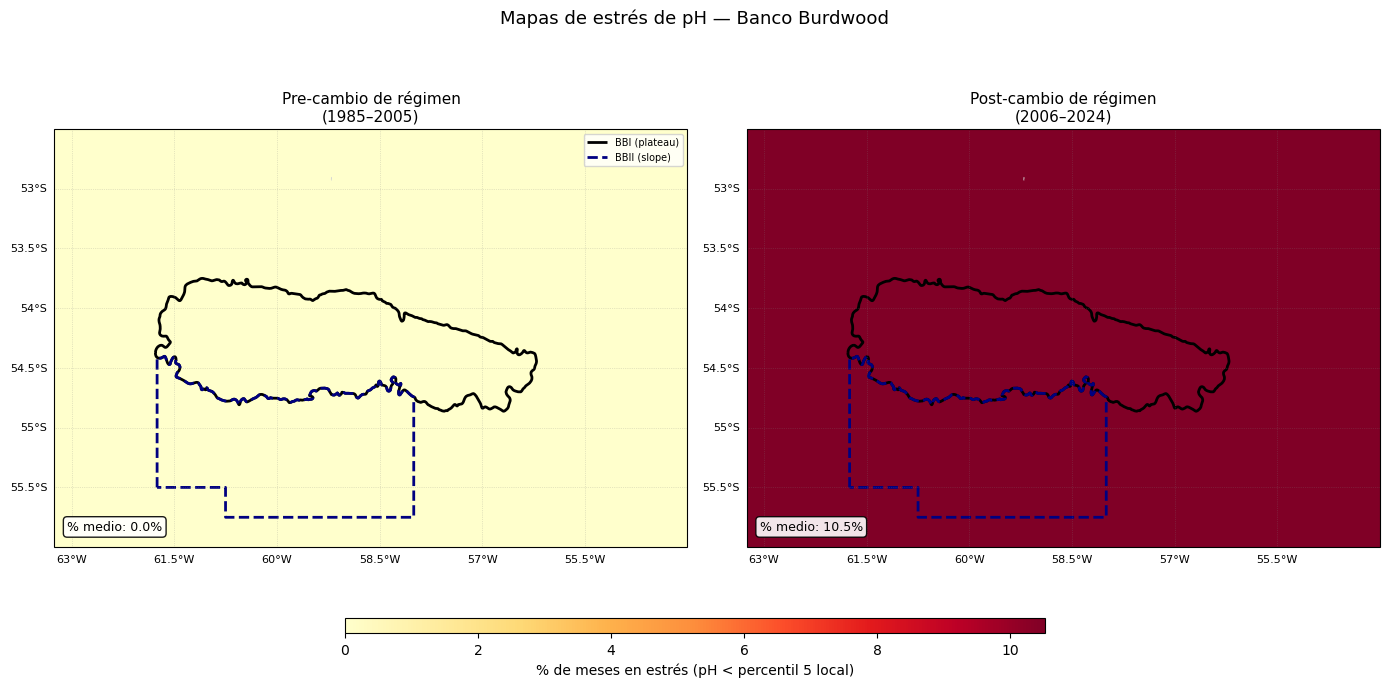

✅ stress_maps_pre_post.png


In [8]:
# =============================================================================
# CELDA 7 — Mapas de % de meses en estrés por período (P1 y P2)
# =============================================================================
 
def stress_pct_map(stress_mask, year_start, year_end):
    """% de meses en estrés por píxel para un período dado."""
    mask_period = stress_mask.sel(
        time=stress_mask.time.dt.year.isin(range(year_start, year_end + 1))
    )
    return 100 * mask_period.sum(dim="time") / mask_period.sizes["time"]
 
 
# Calcular sobre bbox completo (para los mapas)
stress_mask_bbox = ph < ph_p05
pct_pre  = stress_pct_map(stress_mask_bbox, *PERIOD_PRE)
pct_post = stress_pct_map(stress_mask_bbox, *PERIOD_POST)
 
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw={"projection": proj})
 
# Escala compartida
all_vals = np.concatenate([pct_pre.values.ravel(), pct_post.values.ravel()])
vmax     = np.nanpercentile(all_vals, 98)
 
for ax, pct_map, title, color_line in [
    (axes[0], pct_pre,  f"Pre-cambio de régimen\n(1985–2005)", "#2166ac"),
    (axes[1], pct_post, f"Post-cambio de régimen\n(2006–2024)", "#d6604d"),
]:
    im = pct_map.plot(
        ax=ax, transform=proj,
        cmap="YlOrRd", vmin=0, vmax=vmax,
        add_colorbar=False, add_labels=False,
    )
 
    bbi_shape.boundary.plot(ax=ax, transform=proj,
                             color="black", linewidth=2, label="BBI (plateau)")
    bbii_shape.boundary.plot(ax=ax, transform=proj,
                              color="navy", linewidth=2,
                              linestyle="--", label="BBII (slope)")
    ax.coastlines(resolution="10m", color="black", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
 
    gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                       color="gray", alpha=0.4, linestyle=":")
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}
 
    ax.text(0.02, 0.04, f"% medio: {float(pct_map.mean()):.1f}%",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)
    ax.set_title(title, fontsize=11, pad=6)
 
axes[0].legend(loc="upper right", fontsize=7)
 
cbar_ax = fig.add_axes([0.25, -0.02, 0.5, 0.025])
sm = plt.cm.ScalarMappable(cmap="YlOrRd",
                            norm=mcolors.Normalize(vmin=0, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
             label="% de meses en estrés (pH < percentil 5 local)")
 
plt.suptitle("Mapas de estrés de pH — Banco Burdwood", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stress_maps_pre_post.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ stress_maps_pre_post.png")

#### Mapas de pH invernal pre/post y diferencia

C:\Users\gisel\AppData\Local\Temp\ipykernel_97880\1529867642.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


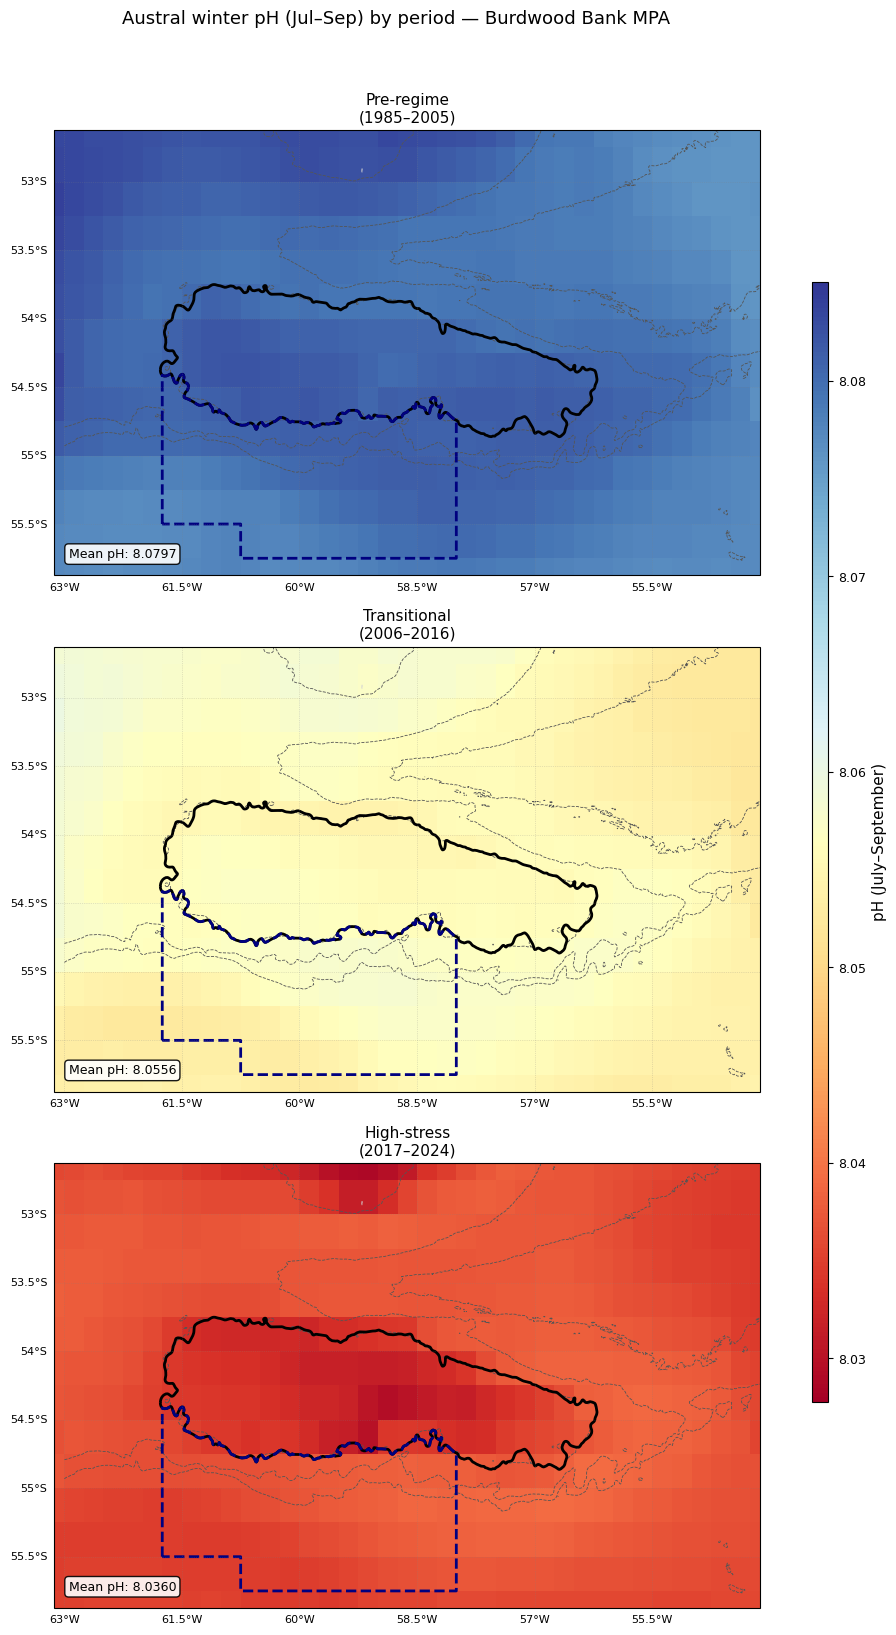

✅ winter_ph_regime_maps.png


In [9]:
# =============================================================================
# CELDA 8 — Mapas de pH invernal pre/post y diferencia
# =============================================================================
 
def winter_mean(da, year_start, year_end, months=WINTER_MONTHS):
    """pH medio del trimestre invernal para un período dado."""
    period = da.sel(time=da.time.dt.year.isin(range(year_start, year_end + 1)))
    winter = period.sel(time=period.time.dt.month.isin(months))
    return winter.mean(dim="time")
 


PERIODOS_MAPAS = [
    (1985, 2005, "Pre-regime\n(1985–2005)"),
    (2006, 2016, "Transitional\n(2006–2016)"),
    (2017, 2024, "High-stress\n(2017–2024)"),
]

ph_maps = [(winter_mean(ph, y1, y2), title) 
           for y1, y2, title in PERIODOS_MAPAS]

vmin_abs = min(float(m.min()) for m, _ in ph_maps) - 0.001
vmax_abs = max(float(m.max()) for m, _ in ph_maps) + 0.001


fig, axes = plt.subplots(3, 1, figsize=(8, 16),
                          subplot_kw={"projection": proj})

plt.rcParams.update({
    "font.size"       : 11,
    "axes.titlesize"  : 12,
    "axes.labelsize"  : 11,
    "xtick.labelsize" : 9,
    "ytick.labelsize" : 9,
})

# --- Paneles 1 y 2: misma escala ---
for ax, (data, title) in zip(axes, ph_maps):
    
    im_abs = data.plot(
        ax=ax, transform=proj,
        cmap="RdYlBu", vmin=vmin_abs, vmax=vmax_abs,
        add_colorbar=False, add_labels=False,
    )
    bath = xr.open_dataset(os.path.join(SHAPES_DIR, "gebco_2025_n-52.0_s-56.0_w-63.0_e-54.0.nc"))["elevation"]
    bath.plot.contour(
    ax=ax, transform=proj,
    levels=[-200, -1000, -2000],
    colors=["#555555"], linewidths=[0.6],
    add_labels=False
    )
    
    bbi_shape.boundary.plot(ax=ax, transform=proj, color="black", linewidth=2)
    bbii_shape.boundary.plot(ax=ax, transform=proj, color="navy", linewidth=2, linestyle="--")
    ax.coastlines(resolution="10m", color="black", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.4, linestyle=":")
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}
    ax.text(0.02, 0.04, f"Mean pH: {float(data.mean()):.4f}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_extent([-63.125, -54.125, -55.875, -52.625], crs=proj)
# Colorbar compartida para paneles 1 y 2
cbar_ax1 = fig.add_axes([1.02, 0.15, 0.02, 0.7])
sm1 = plt.cm.ScalarMappable(cmap="RdYlBu",
                              norm=mcolors.Normalize(vmin=vmin_abs, vmax=vmax_abs))
sm1.set_array([])
fig.colorbar(sm1, cax=cbar_ax1, orientation="vertical", label="pH (July–September)")

 
plt.suptitle(
    "Austral winter pH (Jul–Sep) by period — Burdwood Bank MPA",
    fontsize=13, y=1.02
)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "winter_ph_regime_maps.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ winter_ph_regime_maps.png")

In [10]:
print(f"lon: {float(ph.longitude.min()):.3f} → {float(ph.longitude.max()):.3f}")
print(f"lat: {float(ph.latitude.min()):.3f} → {float(ph.latitude.max()):.3f}")

lon: -63.125 → -54.125
lat: -55.875 → -52.625


#### Resumen cuantitativo para el paper

In [11]:
# =============================================================================
# CELDA 9 — Resumen cuantitativo para el paper
# =============================================================================
print(f"\n  pH INVERNAL (jul–sep) POR PERÍODO:")
for (y1, y2, label), (ph_map, _) in zip(PERIODOS_MAPAS, ph_maps):
    print(f"    {label.replace(chr(10), ' ')}: {float(ph_map.mean()):.4f}")

ph_pre  = ph_maps[0][0]
ph_tran = ph_maps[1][0]
ph_est  = ph_maps[2][0]
print(f"\n    Δ pre→transición : {float(ph_tran.mean()) - float(ph_pre.mean()):.4f}")
print(f"    Δ pre→estrés     : {float(ph_est.mean())  - float(ph_pre.mean()):.4f}")
print(f"    Δ transición→estrés: {float(ph_est.mean()) - float(ph_tran.mean()):.4f}")


  pH INVERNAL (jul–sep) POR PERÍODO:
    Pre-regime (1985–2005): 8.0797
    Transitional (2006–2016): 8.0556
    High-stress (2017–2024): 8.0360

    Δ pre→transición : -0.0240
    Δ pre→estrés     : -0.0437
    Δ transición→estrés: -0.0196


#### mapas con aragonita y spco2

C:\Users\gisel\AppData\Local\Temp\ipykernel_97880\1992483180.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


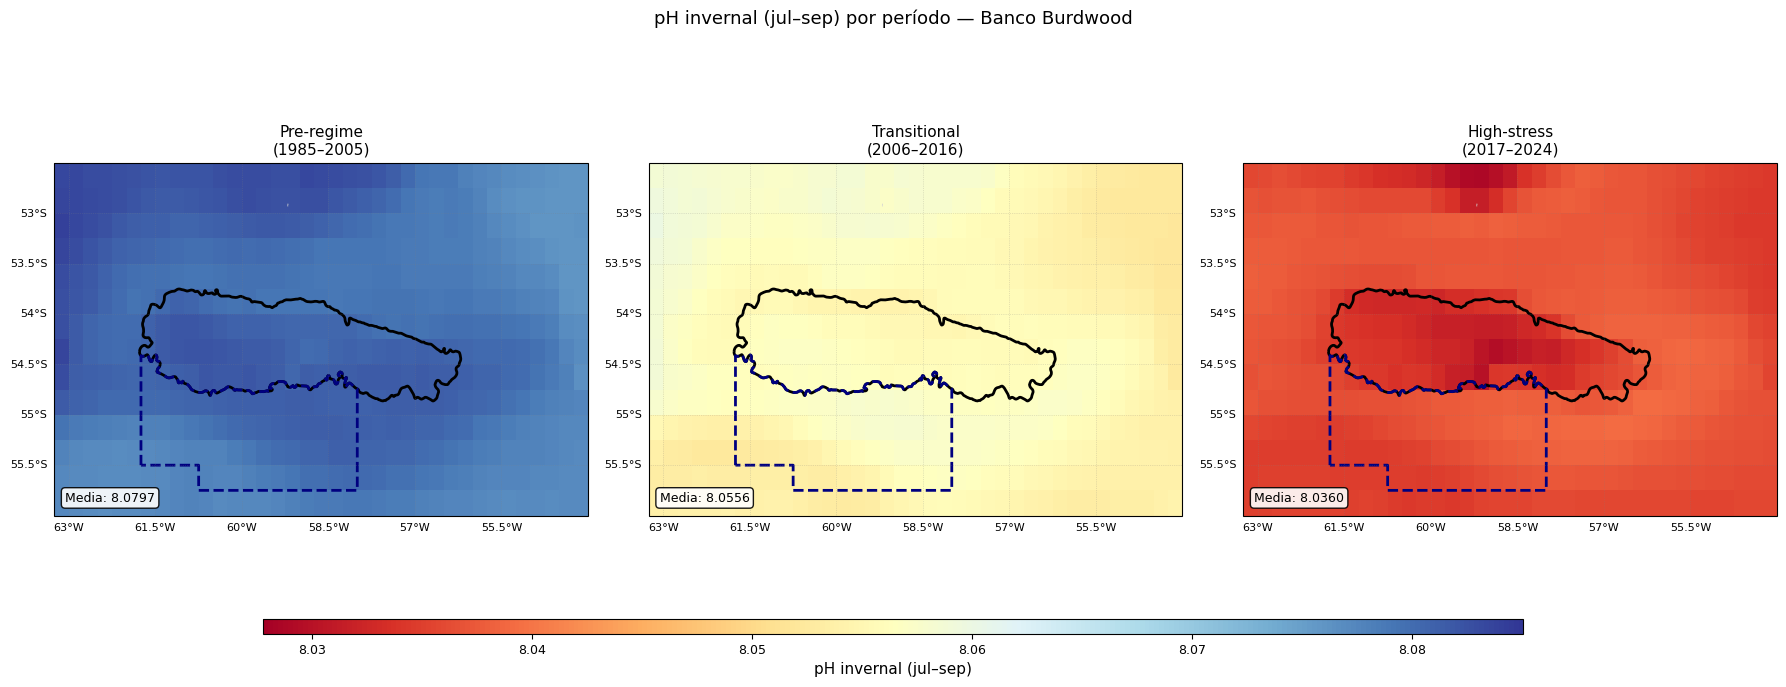

✅ winter_ph_maps.png


C:\Users\gisel\AppData\Local\Temp\ipykernel_97880\1992483180.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


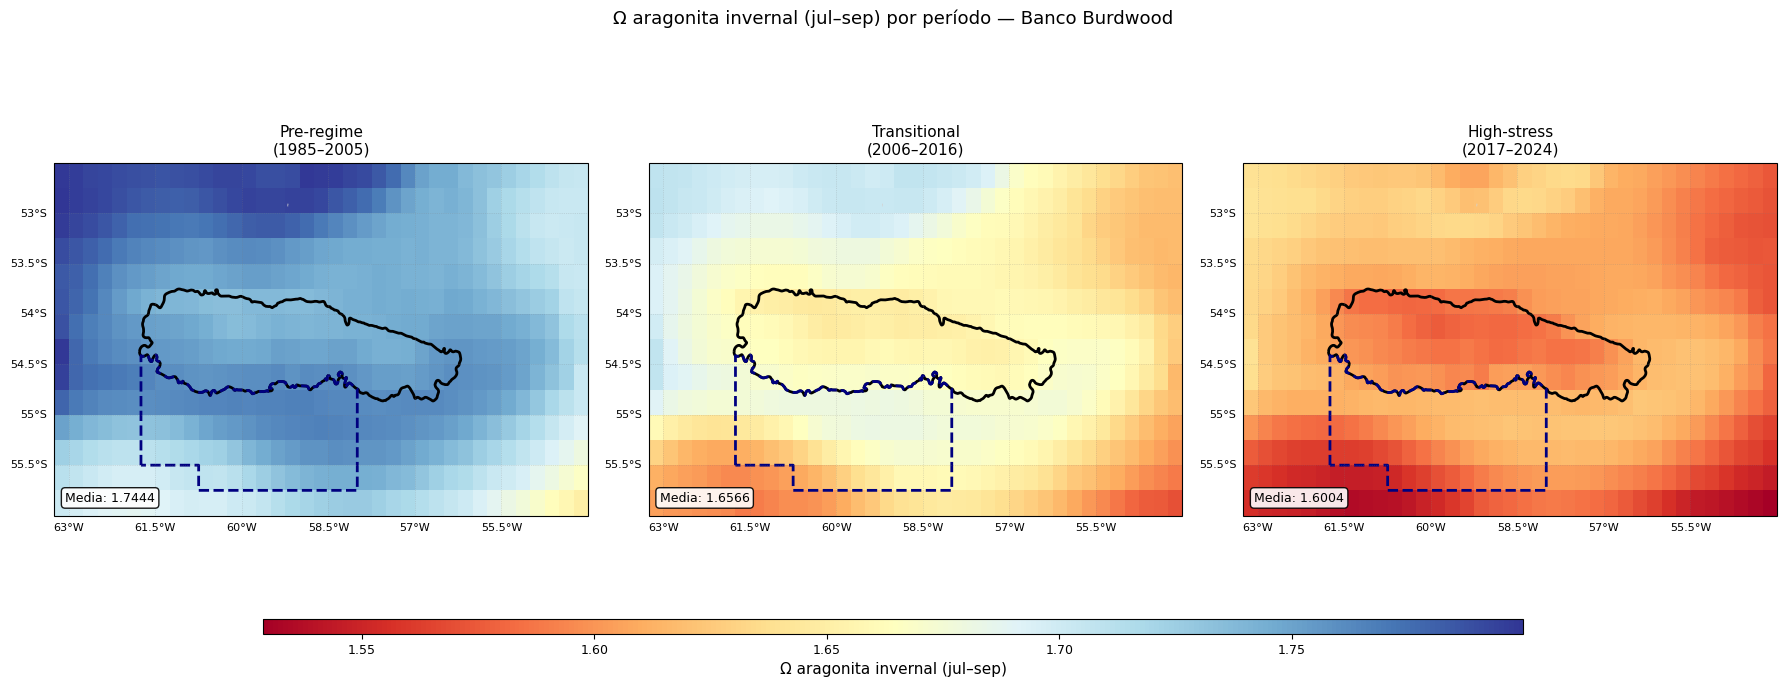

✅ winter_omega_ar_maps.png


C:\Users\gisel\AppData\Local\Temp\ipykernel_97880\1992483180.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


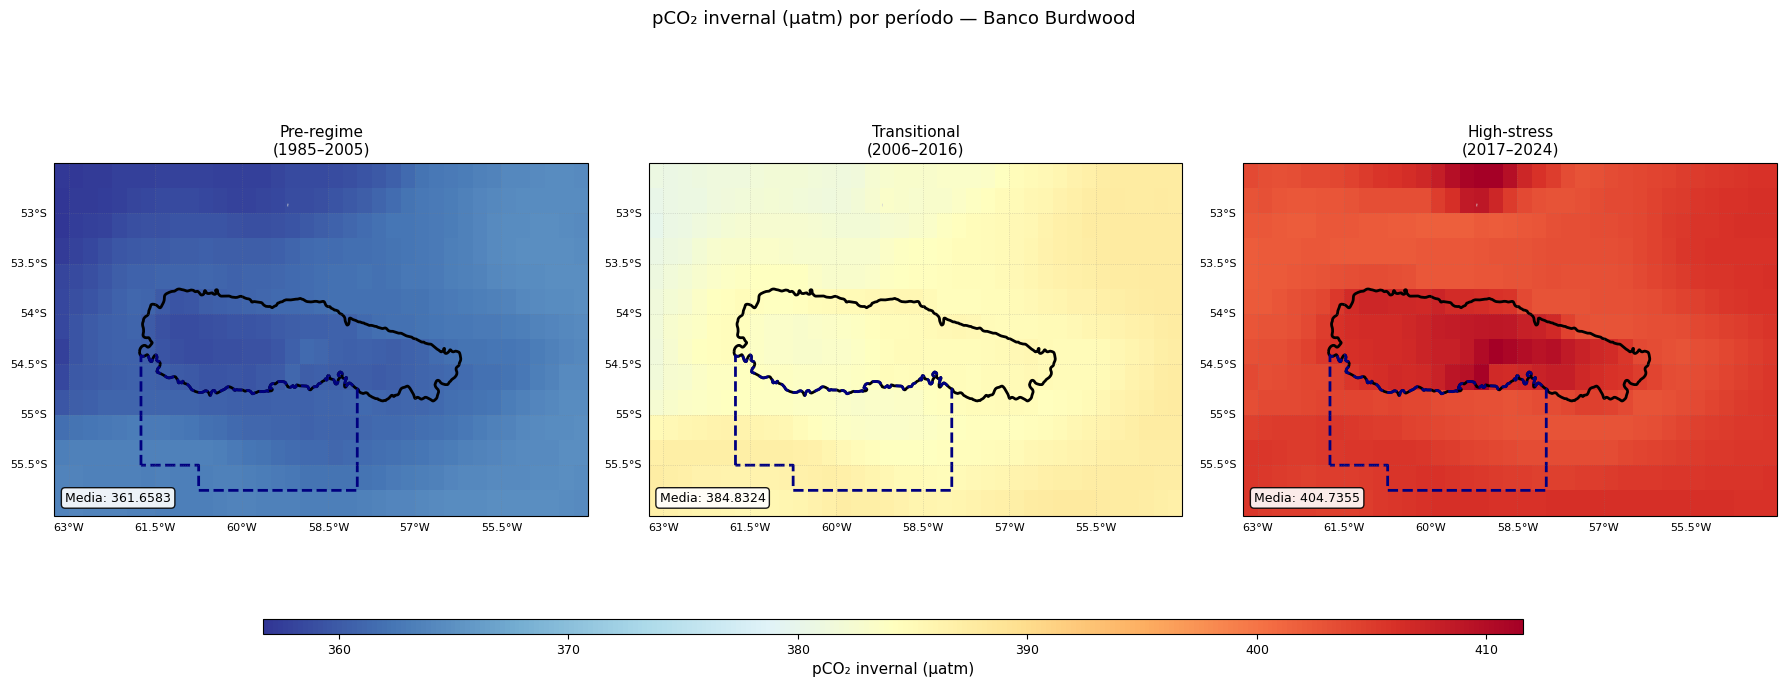

✅ winter_spco2_maps.png


In [12]:
VARIABLES_MAPAS = [
    ("ph",       "pH invernal (jul–sep)",         "RdYlBu"),
    ("omega_ar", "Ω aragonita invernal (jul–sep)", "RdYlBu"),
    ("spco2",    "pCO₂ invernal (µatm)",           "RdYlBu_r"),
]

for varname, var_label, cmap in VARIABLES_MAPAS:
    da = ds[varname]
    ph_maps = [(winter_mean(da, y1, y2), title)
               for y1, y2, title in PERIODOS_MAPAS]

    vmin_abs = min(float(m.min()) for m, _ in ph_maps) - 0.001
    vmax_abs = max(float(m.max()) for m, _ in ph_maps) + 0.001

    fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                              subplot_kw={"projection": proj})

    for ax, (data, title) in zip(axes, ph_maps):
        im = data.plot(
            ax=ax, transform=proj,
            cmap=cmap, vmin=vmin_abs, vmax=vmax_abs,
            add_colorbar=False, add_labels=False,
        )
        bbi_shape.boundary.plot(ax=ax, transform=proj,
                                 color="black", linewidth=2)
        bbii_shape.boundary.plot(ax=ax, transform=proj,
                                  color="navy", linewidth=2, linestyle="--")
        ax.coastlines(resolution="10m", color="black", linewidth=0.8)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                           color="gray", alpha=0.4, linestyle=":")
        gl.top_labels = False; gl.right_labels = False
        gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}
        ax.text(0.02, 0.04, f"Media: {float(data.mean()):.4f}",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)
        ax.set_title(title, fontsize=11, pad=6)

    cbar_ax = fig.add_axes([0.15, -0.02, 0.7, 0.025])
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=mcolors.Normalize(vmin=vmin_abs, vmax=vmax_abs))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", label=var_label)

    plt.suptitle(f"{var_label} por período — Banco Burdwood", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"winter_{varname}_maps.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ winter_{varname}_maps.png")

#### mapas con puntos de cambio de regimen adaptado por variable

In [13]:
PERIODOS_POR_VAR = {
    "ph"      : [(1985, 2005, "Pre-régimen\n(1985–2005)"),
                 (2006, 2016, "Transición\n(2006–2016)"),
                 (2017, 2024, "Estrés intenso\n(2017–2024)")],
    "omega_ar": [(1985, 2006, "Pre-régimen\n(1985–2006)"),
                 (2007, 2016, "Transición\n(2007–2016)"),
                 (2017, 2024, "Estrés intenso\n(2017–2024)")],
    "spco2"   : [(1985, 2005, "Pre-régimen\n(1985–2005)"),
                 (2006, 2016, "Transición\n(2006–2016)"),
                 (2017, 2024, "Estrés intenso\n(2017–2024)")],
}

C:\Users\gisel\AppData\Local\Temp\ipykernel_97880\3882085719.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


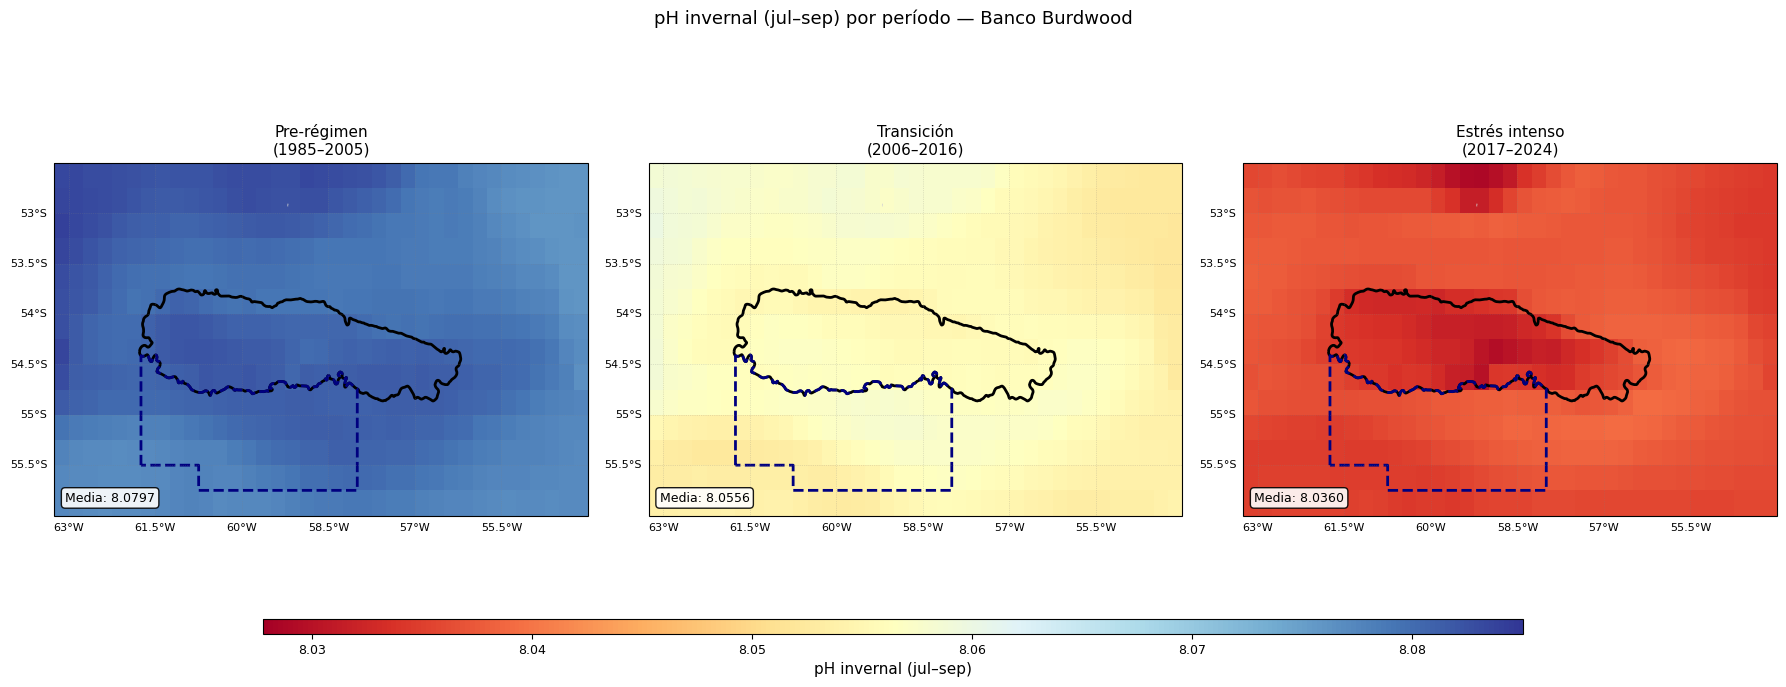

✅ winter_ph_maps.png


C:\Users\gisel\AppData\Local\Temp\ipykernel_97880\3882085719.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


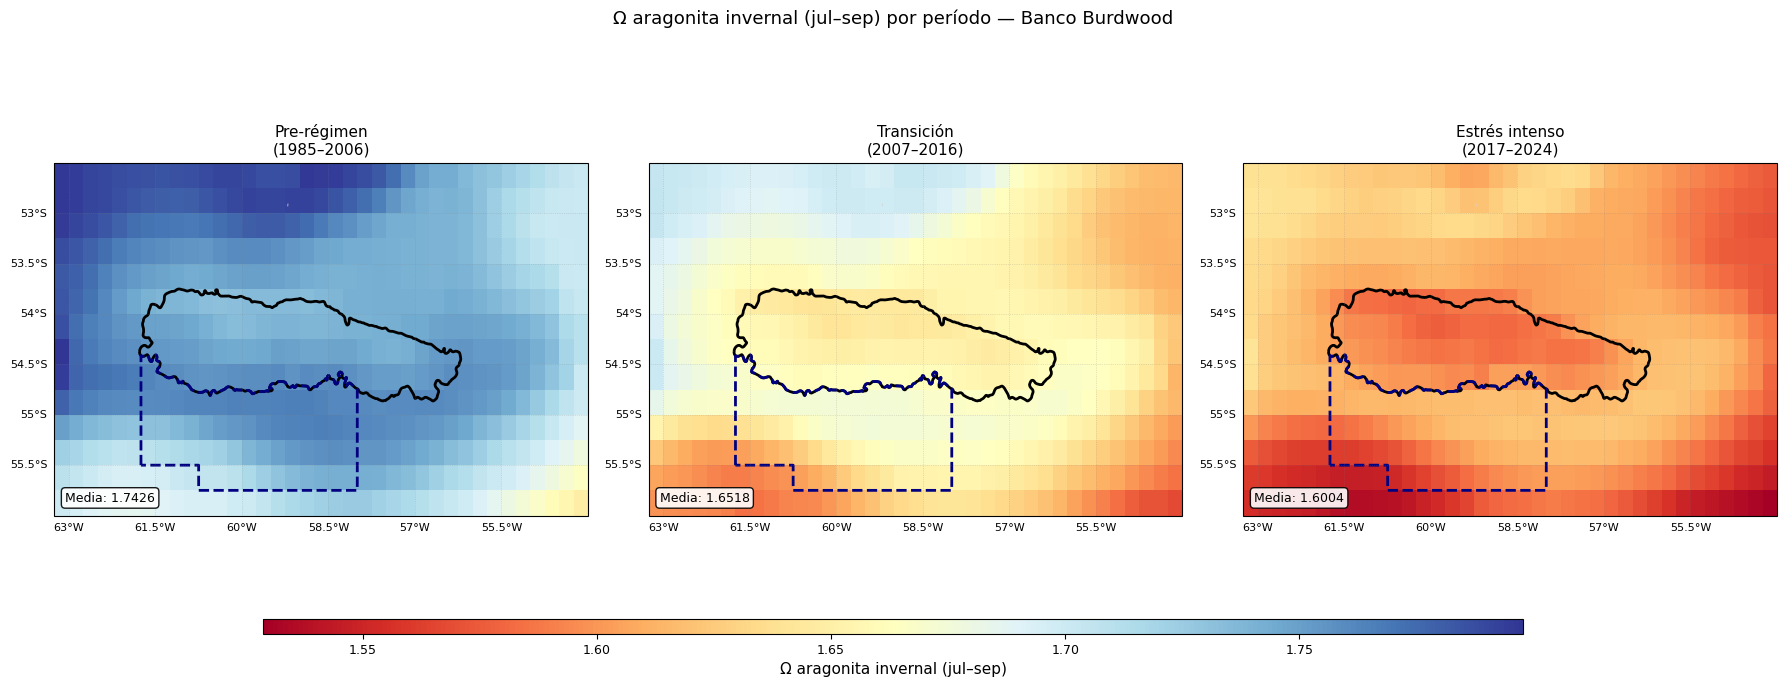

✅ winter_omega_ar_maps.png


C:\Users\gisel\AppData\Local\Temp\ipykernel_97880\3882085719.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


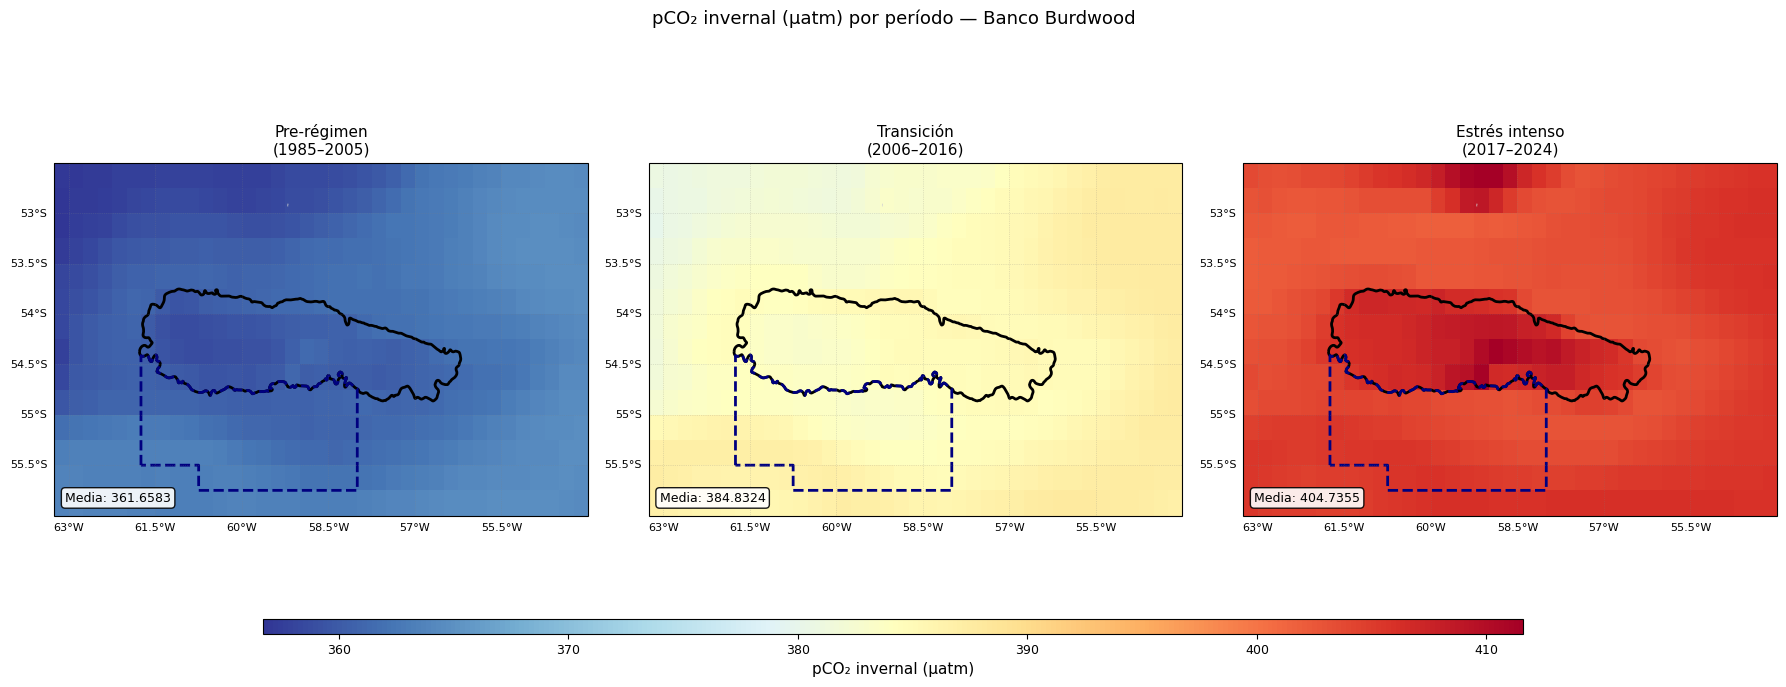

✅ winter_spco2_maps.png


In [14]:
VARIABLES_MAPAS = [
    ("ph",       "pH invernal (jul–sep)",         "RdYlBu"),
    ("omega_ar", "Ω aragonita invernal (jul–sep)", "RdYlBu"),
    ("spco2",    "pCO₂ invernal (µatm)",           "RdYlBu_r"),
]

for varname, var_label, cmap in VARIABLES_MAPAS:
    da = ds[varname]
    periodos = PERIODOS_POR_VAR[varname]
    ph_maps  = [(winter_mean(da, y1, y2), title) for y1, y2, title in periodos]

    vmin_abs = min(float(m.min()) for m, _ in ph_maps) - 0.001
    vmax_abs = max(float(m.max()) for m, _ in ph_maps) + 0.001

    fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                              subplot_kw={"projection": proj})

    for ax, (data, title) in zip(axes, ph_maps):
        im = data.plot(
            ax=ax, transform=proj,
            cmap=cmap, vmin=vmin_abs, vmax=vmax_abs,
            add_colorbar=False, add_labels=False,
        )
        bbi_shape.boundary.plot(ax=ax, transform=proj,
                                 color="black", linewidth=2)
        bbii_shape.boundary.plot(ax=ax, transform=proj,
                                  color="navy", linewidth=2, linestyle="--")
        ax.coastlines(resolution="10m", color="black", linewidth=0.8)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                           color="gray", alpha=0.4, linestyle=":")
        gl.top_labels = False; gl.right_labels = False
        gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}
        ax.text(0.02, 0.04, f"Media: {float(data.mean()):.4f}",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)
        ax.set_title(title, fontsize=11, pad=6)

    cbar_ax = fig.add_axes([0.15, -0.02, 0.7, 0.025])
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=mcolors.Normalize(vmin=vmin_abs, vmax=vmax_abs))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", label=var_label)

    plt.suptitle(f"{var_label} por período — Banco Burdwood", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"winter_{varname}_maps.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ winter_{varname}_maps.png")

### Fig 4 para el paper

C:\Users\gisel\AppData\Local\Temp\ipykernel_97880\759806601.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])


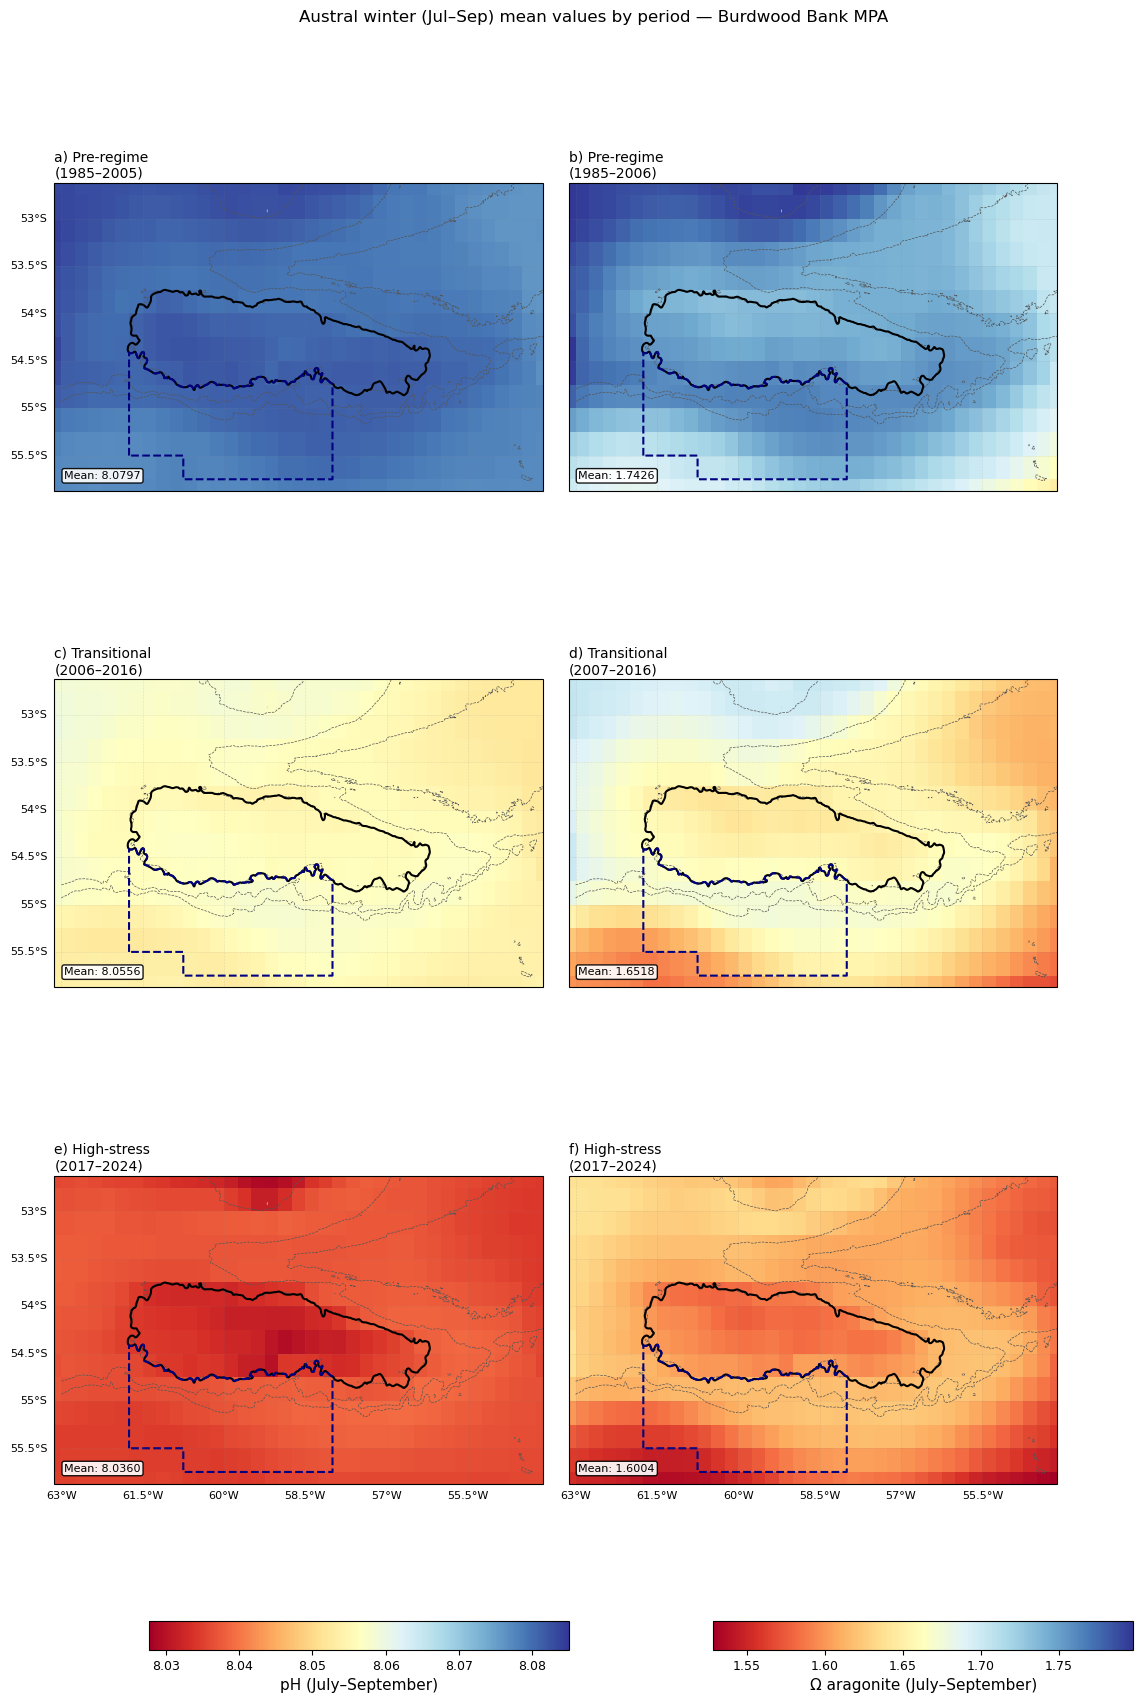

✅ Fig4_winter_maps.png guardada


In [15]:
WINTER_MONTHS = [7, 8, 9]
 
plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 11,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

# =============================================================================
# Cargar datos y shapes
# =============================================================================
 
ds         = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_bbox_ready.nc"))
bbi_shape  = gpd.read_file(os.path.join(SHAPES_DIR, "transicion_solo.shp"))
bbii_shape = gpd.read_file(os.path.join(SHAPES_DIR, "BBII_unificado.shp"))
bath       = xr.open_dataset(os.path.join(SHAPES_DIR,
             "gebco_2025_n-52.0_s-56.0_w-63.0_e-54.0.nc"))["elevation"]
 
 
def winter_mean(da, y1, y2):
    period = da.sel(time=da.time.dt.year.isin(range(y1, y2 + 1)))
    winter = period.sel(time=period.time.dt.month.isin(WINTER_MONTHS))
    return winter.mean(dim="time")
 
 
# Períodos por variable (cambio de régimen distinto)
COLS = [
    {
        "varname"  : "ph",
        "cmap"     : "RdYlBu",
        "cbar_label": "pH (July–September)",
        "mean_fmt" : ".4f",
        "periods"  : [
            (1985, 2005, "a) Pre-regime\n(1985–2005)"),
            (2006, 2016, "c) Transitional\n(2006–2016)"),
            (2017, 2024, "e) High-stress\n(2017–2024)"),
        ],
    },
    {
        "varname"  : "omega_ar",
        "cmap"     : "RdYlBu",
        "cbar_label": "Ω aragonite (July–September)",
        "mean_fmt" : ".4f",
        "periods"  : [
            (1985, 2006, "b) Pre-regime\n(1985–2006)"),
            (2007, 2016, "d) Transitional\n(2007–2016)"),
            (2017, 2024, "f) High-stress\n(2017–2024)"),
        ],
    },
]
 
# =============================================================================
# Calcular mapas y escalas
# =============================================================================
 
for col in COLS:
    da = ds[col["varname"]]
    col["maps"] = [(winter_mean(da, y1, y2), title)
                   for y1, y2, title in col["periods"]]
    col["vmin"] = min(float(m.min()) for m, _ in col["maps"]) - 0.001
    col["vmax"] = max(float(m.max()) for m, _ in col["maps"]) + 0.001
 
# =============================================================================
# Figura: 3 filas × 2 columnas
# =============================================================================
 
proj = ccrs.PlateCarree()
EXTENT = [-63.125, -54.125, -55.875, -52.625]
 
fig, axes = plt.subplots(3, 2, figsize=(12, 16),
                          subplot_kw={"projection": proj})
 
for c, col in enumerate(COLS):
    for r, (data, title) in enumerate(col["maps"]):
        ax = axes[r, c]
 
        # Mapa
        ax.pcolormesh(
            data.longitude, data.latitude, data.values,
            transform=proj,
            cmap=col["cmap"],
            vmin=col["vmin"], vmax=col["vmax"],
        )
 
        # Batimetría
        lons = bath.lon.values if "lon" in bath.coords else bath.longitude.values
        lats = bath.lat.values if "lat" in bath.coords else bath.latitude.values
        ax.contour(lons, lats, bath.values,
                   levels=[-2000, -1000, -200],
                   colors=["#555555"], linewidths=[0.5],
                   transform=proj)
 
        # Shapes
        bbi_shape.boundary.plot(ax=ax, transform=proj,
                                 color="black", linewidth=1.5)
        bbii_shape.boundary.plot(ax=ax, transform=proj,
                                  color="navy", linewidth=1.5, linestyle="--")
 
        # Coastline y land
        ax.coastlines(resolution="10m", color="black", linewidth=0.8)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
 
        # Grilla
        gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                           color="gray", alpha=0.4, linestyle=":")
        gl.top_labels   = False
        gl.right_labels = False
        gl.left_labels  = (c == 0)   # etiquetas Y solo en columna izquierda
        gl.bottom_labels = (r == 2)  # etiquetas X solo en fila inferior
        gl.xlabel_style = {"size": 8}
        gl.ylabel_style = {"size": 8}
 
        # Anotación media
        fmt = col["mean_fmt"]
        ax.text(0.02, 0.04,
                f"Mean: {float(data.mean()):{fmt}}",
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.9),
                zorder=5)
 
        ax.set_title(title, fontsize=10, loc="left", pad=4)
        ax.set_extent(EXTENT, crs=proj)
 
    # Colorbar por columna
    cbar_ax = fig.add_axes([
        0.13 + c * 0.47,  # x
        -0.02,             # y — debajo de la figura
        0.35,              # width
        0.018              # height
    ])
    sm = plt.cm.ScalarMappable(
        cmap=col["cmap"],
        norm=mcolors.Normalize(vmin=col["vmin"], vmax=col["vmax"])
    )
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
                 label=col["cbar_label"])
 
plt.suptitle(
    "Austral winter (Jul–Sep) mean values by period — Burdwood Bank MPA",
    fontsize=12, y=1.005
)
 
plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.savefig(os.path.join(FIGURES_DIR, "Fig4_winter_maps.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Fig4_winter_maps.png guardada")
 

In [16]:
omega_ar_bbox = ds["omega_ar"].where(inside)
omega_ar_p05  = omega_ar_bbox.quantile(0.05, dim="time")

print(f"Ω_ar percentil 5 — rango espacial:")
print(f"  min : {float(omega_ar_p05.min()):.4f}")
print(f"  max : {float(omega_ar_p05.max()):.4f}")
print(f"  mean: {float(omega_ar_p05.mean()):.4f}")
print(f"\nComparación con umbral biológico (1.5):")
print(f"  % píxeles con p5 < 1.5: {float((omega_ar_p05 < 1.5).mean()*100):.1f}%")

Ω_ar percentil 5 — rango espacial:
  min : 1.5448
  max : 1.6402
  mean: 1.6094

Comparación con umbral biológico (1.5):
  % píxeles con p5 < 1.5: 0.0%


C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [17]:
# Mínimo absoluto
print(f"Min absoluto: {float(omega_ar_bbox.min()):.4f}")
print(f"Max absoluto: {float(omega_ar_bbox.max()):.4f}")

# Mínimo anual — primero promediar espacialmente, luego mínimo mensual por año
omega_ar_spatial_min = omega_ar_bbox.min(dim=["latitude", "longitude"])
df_min = omega_ar_spatial_min.to_dataframe(name="min_omega_ar").reset_index()
df_min["year"] = pd.to_datetime(df_min["time"]).dt.year

annual_min = df_min.groupby("year")["min_omega_ar"].min()
print("\nMínimo anual (últimos 10 años):")
print(annual_min.tail(10).to_string())

Min absoluto: 1.4501
Max absoluto: 2.3221

Mínimo anual (últimos 10 años):
year
2015    1.518281
2016    1.482607
2017    1.497986
2018    1.544811
2019    1.450111
2020    1.533723
2021    1.536216
2022    1.528469
2023    1.507498
2024    1.499275


In [18]:
# ¿Cuántos meses por píxel tienen Ω_ar < 1.5?
n_below = (omega_ar_bbox < 1.5).sum(dim="time")
pct_months_below = 100 * n_below / omega_ar_bbox.sizes["time"]

print(f"% meses con Ω_ar < 1.5 por píxel:")
print(f"  max en cualquier píxel: {float(pct_months_below.max()):.2f}%")
print(f"  mean en todos los píxeles: {float(pct_months_below.mean()):.2f}%")
print(f"  (el percentil 5 requiere >5% → ningún píxel llega)")

% meses con Ω_ar < 1.5 por píxel:
  max en cualquier píxel: 0.62%
  mean en todos los píxeles: 0.02%
  (el percentil 5 requiere >5% → ningún píxel llega)


### Fig 5 (no se usa)


C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Primer evento pH    : 2017-08
Primer evento Ω_ar  : 2016-06


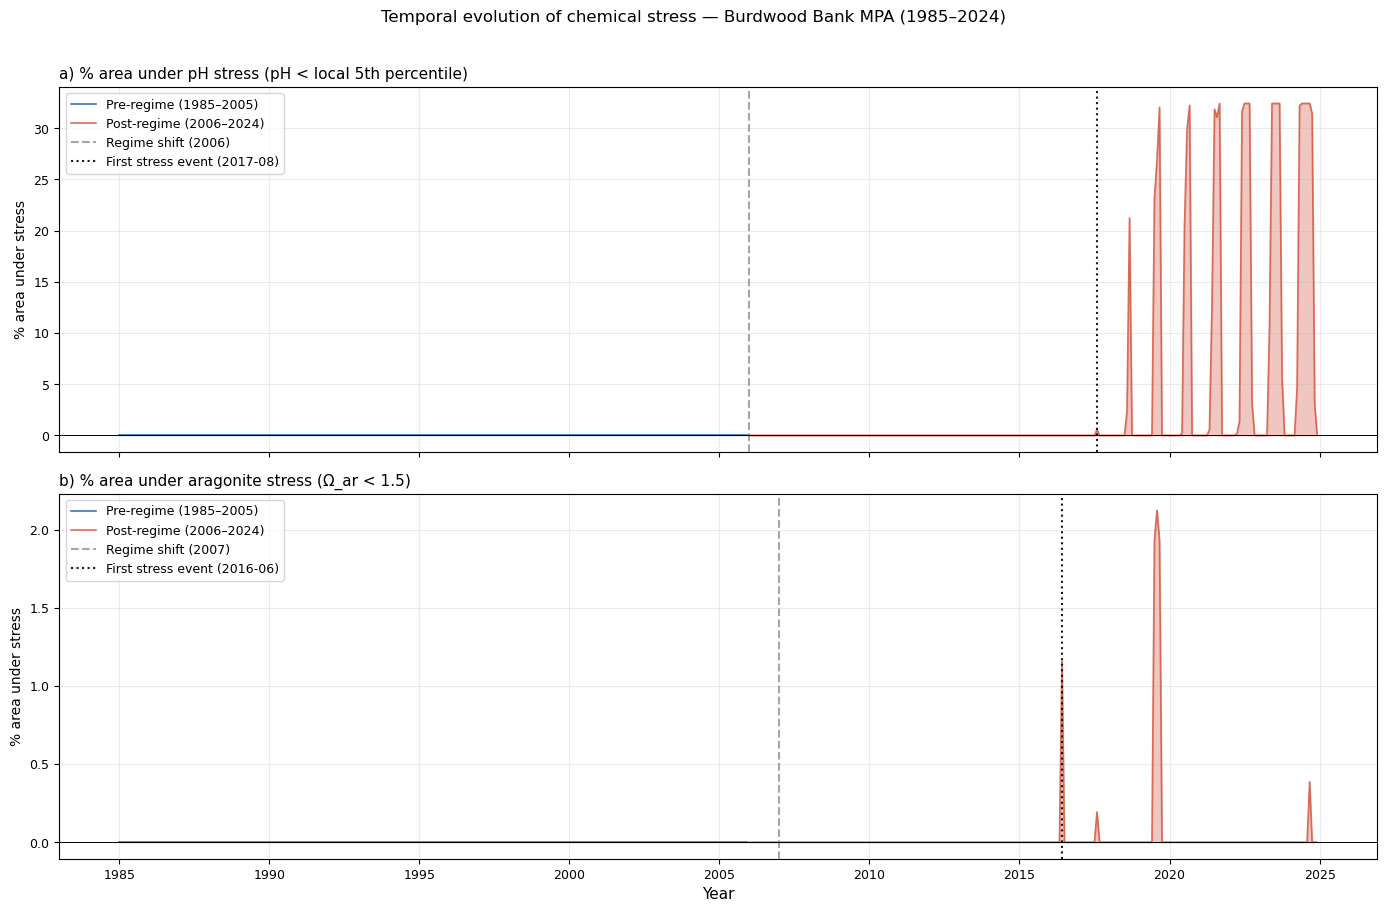

✅ Fig5_stress_timeseries.png guardada


In [19]:
plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 11,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})
 
# =============================================================================
# Cargar datos y máscara BBI+BBII
# =============================================================================
 
ds         = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_bbox_ready.nc"))
ph         = ds["ph"]
omega_ar   = ds["omega_ar"]
 
bbi_shape  = gpd.read_file(os.path.join(SHAPES_DIR, "transicion_solo.shp"))
bbii_shape = gpd.read_file(os.path.join(SHAPES_DIR, "BBII_unificado.shp"))
 
# Máscara BBI+BBII
bb_total = unary_union([bbi_shape.geometry.union_all(),
                         bbii_shape.geometry.union_all()])
lats = ph.latitude.values
lons = ph.longitude.values
LON, LAT = np.meshgrid(lons, lats)
res    = 0.25
pixels = [box(lo-res/2, la-res/2, lo+res/2, la+res/2)
          for lo, la in zip(LON.ravel(), LAT.ravel())]
inside = np.array([bb_total.intersects(p) for p in pixels]).reshape(LAT.shape)
 
ph_bb       = ph.where(inside)
omega_ar_bb = omega_ar.where(inside)
 
 
# =============================================================================
# Calcular series temporales de % área en estrés
# =============================================================================
 
# pH: percentil 5 local por píxel
ph_p05 = ph_bb.quantile(0.05, dim="time")
stress_ph = ph_bb < ph_p05
 
# Ω_ar: umbral biológico absoluto
THRESH_AR = 1.5
stress_ar = omega_ar_bb < THRESH_AR
 
def pct_stress_ts(stress_mask):
    n_stress = stress_mask.sum(dim=["latitude", "longitude"])
    n_valid  = (~stress_mask.isnull()).sum(dim=["latitude", "longitude"])
    pct = 100 * n_stress / n_valid
    df  = pct.to_dataframe(name="pct_stress").reset_index()
    df["time"]  = pd.to_datetime(df["time"])
    df["year"]  = df["time"].dt.year
    return df
 
df_ph = pct_stress_ts(stress_ph)
df_ar = pct_stress_ts(stress_ar)
 
# Primer evento de estrés
t_first_ph = df_ph[df_ph["pct_stress"] > 0]["time"].min()
t_first_ar = df_ar[df_ar["pct_stress"] > 0]["time"].min()
 
print(f"Primer evento pH    : {t_first_ph.strftime('%Y-%m')}")
print(f"Primer evento Ω_ar  : {t_first_ar.strftime('%Y-%m')}")
 
 
# =============================================================================
# Figura 5: dos paneles
# =============================================================================
 
PERIODS = [
    (1985, 2005, "#2166ac", "Pre-regime (1985–2005)"),
    (2006, 2024, "#d6604d", "Post-regime (2006–2024)"),
]
 
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
 
panels = [
    (axes[0], df_ph, t_first_ph, "2006-01-01",
     "a) % area under pH stress (pH < local 5th percentile)",
     "% area under stress"),
    (axes[1], df_ar, t_first_ar, "2007-01-01",
     f"b) % area under aragonite stress (Ω_ar < {THRESH_AR})",
     "% area under stress"),
]
 
for ax, df, t_first, t_regime, title, ylabel in panels:
    for y1, y2, color, label in PERIODS:
        mask = (df["year"] >= y1) & (df["year"] <= y2)
        ax.fill_between(df.loc[mask, "time"],
                        df.loc[mask, "pct_stress"],
                        alpha=0.35, color=color)
        ax.plot(df.loc[mask, "time"],
                df.loc[mask, "pct_stress"],
                color=color, lw=1.2, alpha=0.9, label=label)
 
    # Línea de cambio de régimen
    ax.axvline(pd.Timestamp(t_regime), color="gray",
               lw=1.5, linestyle="--", alpha=0.7,
               label=f"Regime shift ({t_regime[:4]})")
 
    # Primer evento de estrés
    ax.axvline(t_first, color="black", lw=1.5,
               linestyle=":", alpha=0.9,
               label=f"First stress event ({t_first.strftime('%Y-%m')})")
 
    ax.axhline(0, color="black", lw=0.7)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, loc="left")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(alpha=0.25)
 
axes[1].set_xlabel("Year", fontsize=11)
 
plt.suptitle(
    "Temporal evolution of chemical stress — Burdwood Bank MPA (1985–2024)",
    fontsize=12, y=1.01
)
 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Fig5_stress_timeseries.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Fig5_stress_timeseries.png guardada")
 

In [20]:
# ¿Cuántos píxeles válidos tiene la máscara?
print(f"Píxeles dentro de BBI+BBII: {inside.sum()}")

# ¿Cuándo es el primer evento?
print(f"Primer evento Ω_ar < 1.5: {t_first_ar.strftime('%Y-%m')}")

# ¿Qué % del área es ese primer evento?
first_event = df_ar[df_ar["pct_stress"] > 0].iloc[0]
print(f"  % área en ese mes: {first_event['pct_stress']:.3f}%")
print(f"  Fecha: {first_event['time'].strftime('%Y-%m')}")

Píxeles dentro de BBI+BBII: 168
Primer evento Ω_ar < 1.5: 2016-06
  % área en ese mes: 1.158%
  Fecha: 2016-06


### Figura integrada para el paper

C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


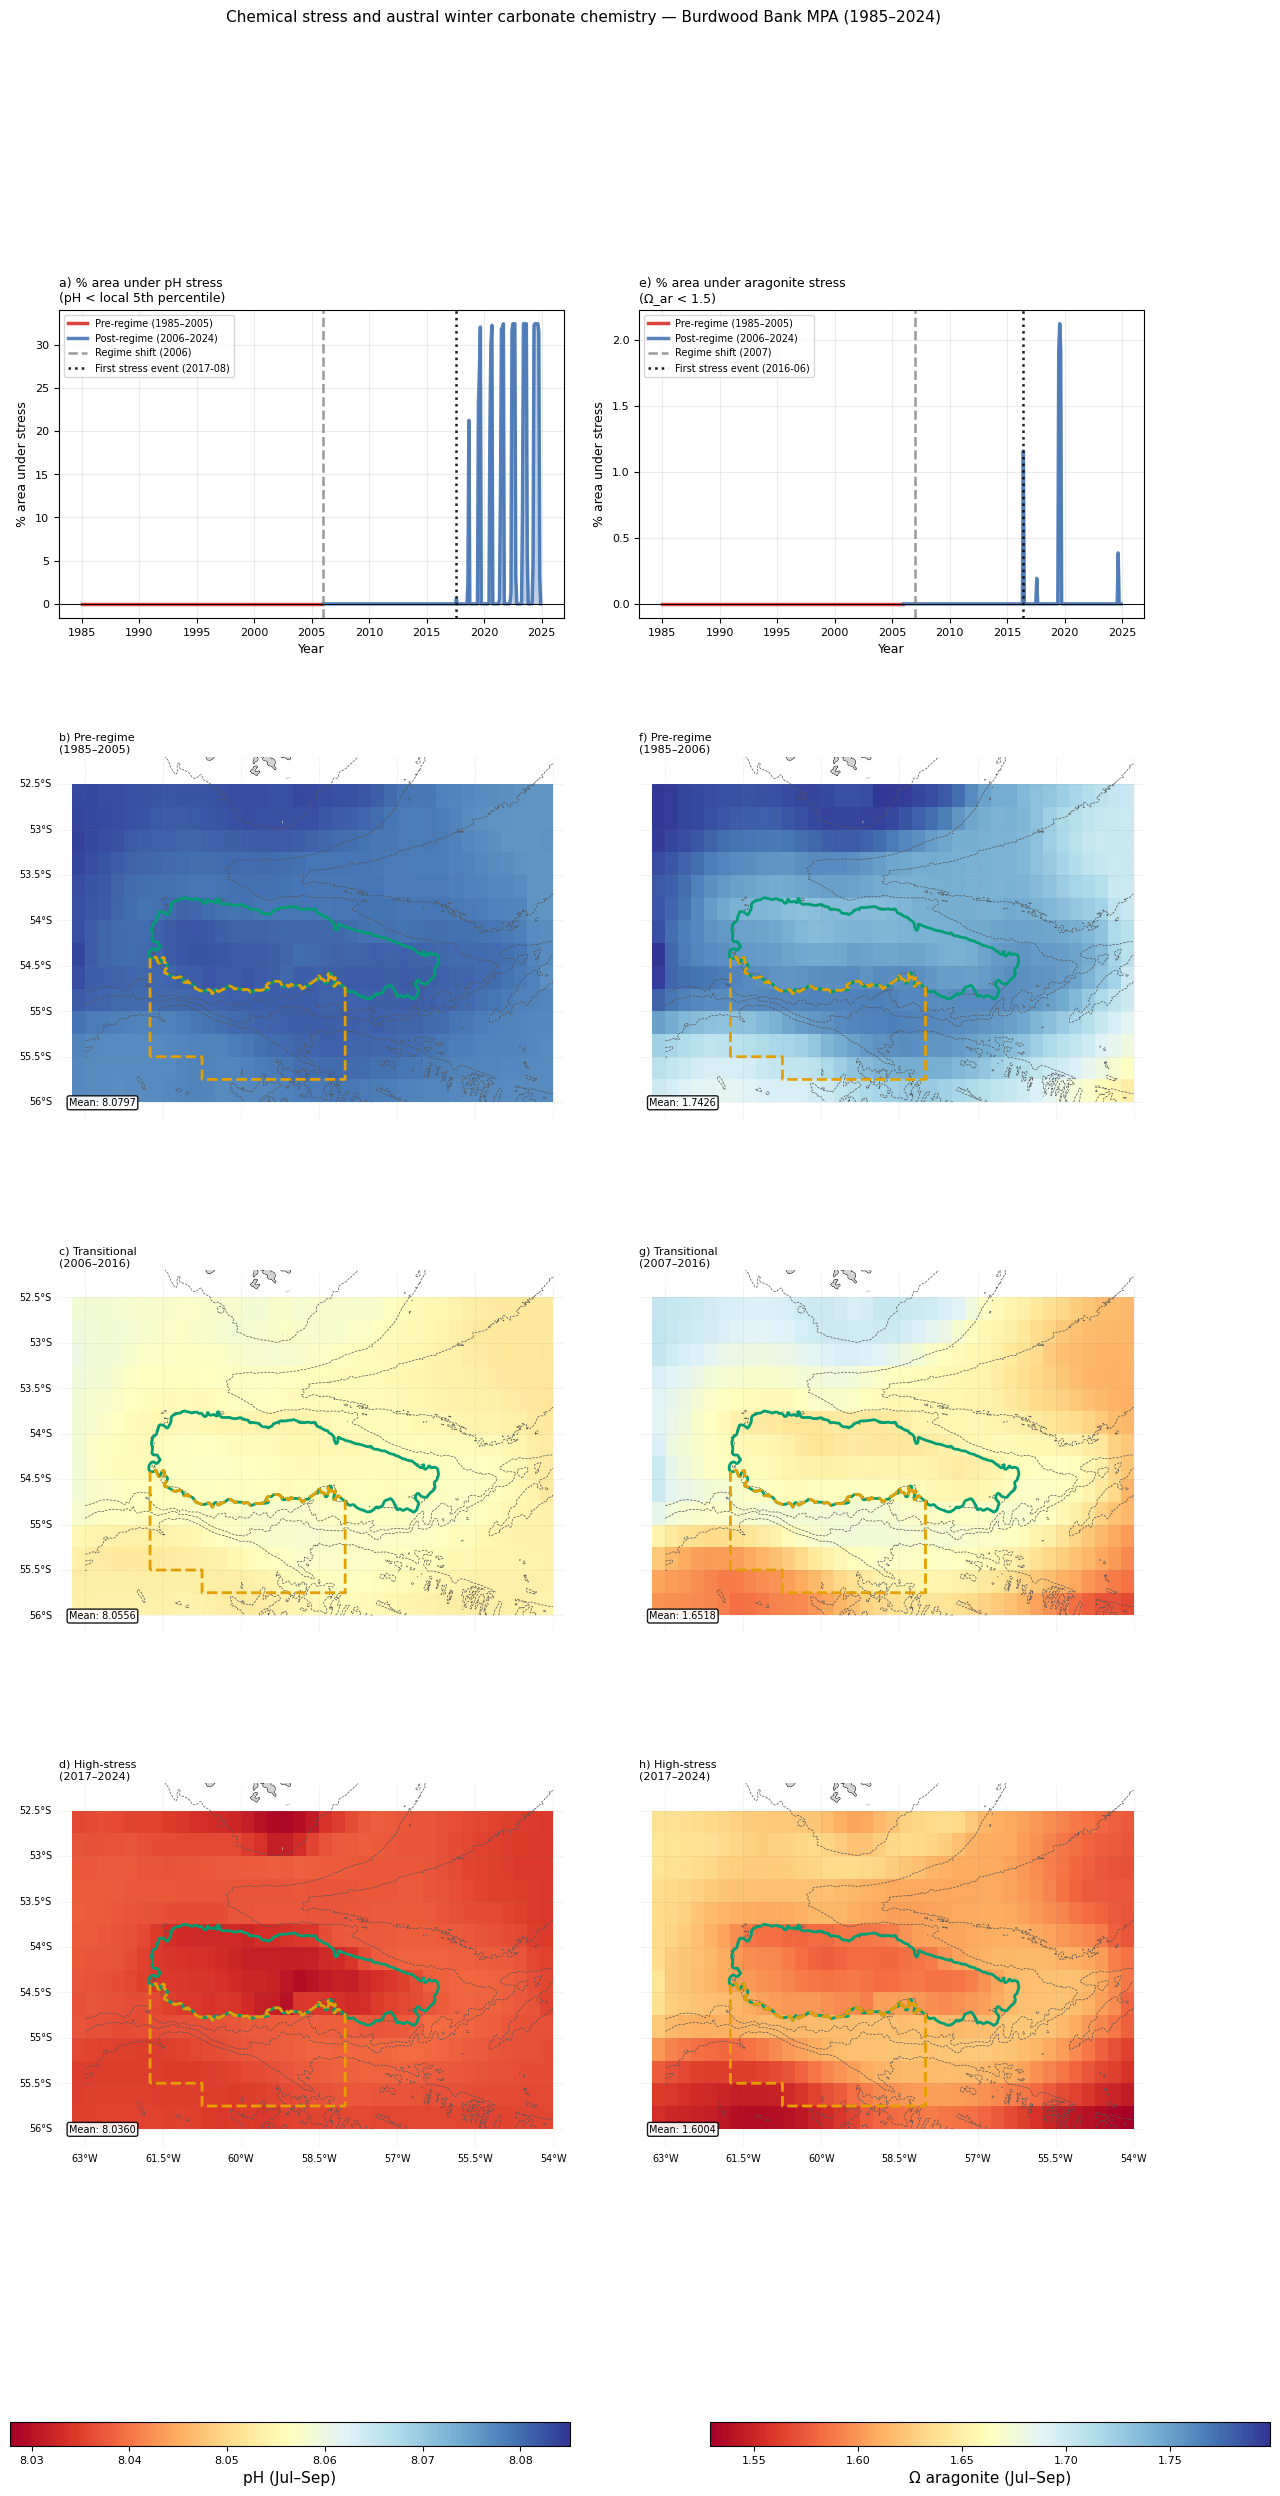

✅ Fig4_stress_maps_integrated.png guardada


<Figure size 640x480 with 0 Axes>

In [23]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
from shapely.ops import unary_union

BASE_DIR      = os.path.abspath("..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed", "pH")
SHAPES_DIR    = os.path.join(BASE_DIR, "data", "raw", "shapes")
FIGURES_DIR   = os.path.join(BASE_DIR, "figures")

WINTER_MONTHS = [7, 8, 9]

# Paleta daltónico-friendly (Wong 2011)
COLOR_BBI    = "#009E73"   # verde — BBI
COLOR_BBII   = "#E69F00"   # naranja — BBII
COLOR_PRE    = "#d73027"   # rojo — período pre-régimen (anomalías positivas)
COLOR_POST   = "#4575b4"   # azul — período post-régimen (anomalías negativas)
COLOR_REGIME = "gray"
COLOR_FIRST  = "black"

plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
})

# =============================================================================
# Cargar datos
# =============================================================================

ds         = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_bbox_ready.nc"))
ph         = ds["ph"]
omega_ar   = ds["omega_ar"]
bbi_shape  = gpd.read_file(os.path.join(SHAPES_DIR, "transicion_solo.shp"))
bbii_shape = gpd.read_file(os.path.join(SHAPES_DIR, "BBII_unificado.shp"))
bath       = xr.open_dataset(os.path.join(SHAPES_DIR,
             "gebco_2025_n-52.0_s-56.0_w-63.0_e-54.0.nc"))["elevation"]

# =============================================================================
# Máscara BBI+BBII
# =============================================================================

bb_total = unary_union([bbi_shape.geometry.union_all(),
                         bbii_shape.geometry.union_all()])
lats = ph.latitude.values
lons = ph.longitude.values
LON, LAT = np.meshgrid(lons, lats)
res    = 0.25
pixels = [box(lo-res/2, la-res/2, lo+res/2, la+res/2)
          for lo, la in zip(LON.ravel(), LAT.ravel())]
inside = np.array([bb_total.intersects(p) for p in pixels]).reshape(LAT.shape)

ph_bb       = ph.where(inside)
omega_ar_bb = omega_ar.where(inside)

# =============================================================================
# Series temporales de estrés
# =============================================================================

ph_p05    = ph_bb.quantile(0.05, dim="time")
stress_ph = ph_bb < ph_p05
stress_ar = omega_ar_bb < 1.5

def pct_stress_ts(stress_mask):
    n_stress = stress_mask.sum(dim=["latitude", "longitude"])
    n_valid  = (~stress_mask.isnull()).sum(dim=["latitude", "longitude"])
    pct = 100 * n_stress / n_valid
    df  = pct.to_dataframe(name="pct_stress").reset_index()
    df["time"] = pd.to_datetime(df["time"])
    df["year"] = df["time"].dt.year
    return df

df_ph = pct_stress_ts(stress_ph)
df_ar = pct_stress_ts(stress_ar)

t_first_ph = df_ph[df_ph["pct_stress"] > 0]["time"].min()
t_first_ar = df_ar[df_ar["pct_stress"] > 0]["time"].min()

# =============================================================================
# Mapas invernales
# =============================================================================

def winter_mean(da, y1, y2):
    period = da.sel(time=da.time.dt.year.isin(range(y1, y2 + 1)))
    winter = period.sel(time=period.time.dt.month.isin(WINTER_MONTHS))
    return winter.mean(dim="time")

COLS = [
    {
        "var"    : "ph",
        "da"     : ph,
        "cmap"   : "RdYlBu",
        "clabel" : "pH (Jul–Sep)",
        "fmt"    : ".4f",
        "regime" : "2006-01-01",
        "t_first": t_first_ph,
        "ts_title": "a) % area under pH stress\n(pH < local 5th percentile)",
        "periods": [
            (1985, 2005, "b) Pre-regime\n(1985–2005)"),
            (2006, 2016, "c) Transitional\n(2006–2016)"),
            (2017, 2024, "d) High-stress\n(2017–2024)"),
        ],
        "df_stress": df_ph,
    },
    {
        "var"    : "omega_ar",
        "da"     : omega_ar,
        "cmap"   : "RdYlBu",
        "clabel" : "Ω aragonite (Jul–Sep)",
        "fmt"    : ".4f",
        "regime" : "2007-01-01",
        "t_first": t_first_ar,
        "ts_title": "e) % area under aragonite stress\n(Ω_ar < 1.5)",
        "periods": [
            (1985, 2006, "f) Pre-regime\n(1985–2006)"),
            (2007, 2016, "g) Transitional\n(2007–2016)"),
            (2017, 2024, "h) High-stress\n(2017–2024)"),
        ],
        "df_stress": df_ar,
    },
]

# Calcular mapas y escalas
for col in COLS:
    col["maps"] = [(winter_mean(col["da"], y1, y2), title)
                   for y1, y2, title in col["periods"]]
    col["vmin"] = min(float(m.min()) for m, _ in col["maps"]) - 0.001
    col["vmax"] = max(float(m.max()) for m, _ in col["maps"]) + 0.001

# =============================================================================
# Figura integrada: 4 filas × 2 columnas
# fila 0: series temporales (altura 1.5)
# filas 1-3: mapas (altura 1 cada una)
# =============================================================================

proj   = ccrs.PlateCarree()
EXTENT = [-63.5, -53.8, -56.2, -52.2]

fig = plt.figure(figsize=(14, 24))
gs  = gridspec.GridSpec(
    4, 2,
    height_ratios=[0.8, 1, 1, 1],
    hspace=0.35, wspace=0.15
)

PERIODS_STRESS = [
    (1985, 2005, COLOR_PRE,  "Pre-regime (1985–2005)"),
    (2006, 2024, COLOR_POST, "Post-regime (2006–2024)"),
]

# --- Fila 0: series temporales ---
for c, col in enumerate(COLS):
    ax = fig.add_subplot(gs[0, c])
    df = col["df_stress"]

    for y1, y2, color, label in PERIODS_STRESS:
        mask = (df["year"] >= y1) & (df["year"] <= y2)
        ax.fill_between(df.loc[mask, "time"],
                        df.loc[mask, "pct_stress"],
                        alpha=0.35, color=color)
        ax.plot(df.loc[mask, "time"],
                df.loc[mask, "pct_stress"],
                color=color, lw=2.5, alpha=0.9, label=label)

    ax.axvline(pd.Timestamp(col["regime"]), color=COLOR_REGIME,
               lw=1.8, linestyle="--", alpha=0.8,
               label=f"Regime shift ({col['regime'][:4]})")
    ax.axvline(col["t_first"], color=COLOR_FIRST,
               lw=1.8, linestyle=":", alpha=0.9,
               label=f"First stress event ({col['t_first'].strftime('%Y-%m')})")

    ax.axhline(0, color="black", lw=0.7)
    ax.set_ylabel("% area under stress", fontsize=9)
    ax.set_title(col["ts_title"], fontsize=9, loc="left")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(alpha=0.25)
    ax.set_xlabel("Year", fontsize=9)

# --- Filas 1-3: mapas ---
for c, col in enumerate(COLS):
    for r, (data, title) in enumerate(col["maps"]):

        ax = fig.add_subplot(gs[r + 1, c], projection=proj)

        # Mapa
        im = ax.pcolormesh(
            data.longitude, data.latitude, data.values,
            transform=proj,
            cmap=col["cmap"],
            vmin=col["vmin"], vmax=col["vmax"],
        )

        # Batimetría
        lons_b = bath.lon.values if "lon" in bath.coords else bath.longitude.values
        lats_b = bath.lat.values if "lat" in bath.coords else bath.latitude.values
        ax.contour(lons_b, lats_b, bath.values,
                   levels=[-4000, -2000, -1000, -200],
                   colors=["#555555"], linewidths=[0.5],
                   transform=proj)

        # Shapes
        bbi_shape.boundary.plot(ax=ax, transform=proj,
                                 color=COLOR_BBI, linewidth=2)
        bbii_shape.boundary.plot(ax=ax, transform=proj,
                                  color=COLOR_BBII, linewidth=2, linestyle="--")

        ax.coastlines(resolution="10m", color="black", linewidth=0.7)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)

        gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                           color="gray", alpha=0.4, linestyle=":")
        gl.top_labels   = False
        gl.right_labels = False
        gl.left_labels  = (c == 0)
        gl.bottom_labels = (r == 2)
        gl.xlabel_style = {"size": 7}
        gl.ylabel_style = {"size": 7}

        ax.text(0.02, 0.04,
                f"Mean: {float(data.mean()):{col['fmt']}}",
                transform=ax.transAxes, fontsize=7,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.9),
                zorder=5)
        ax.set_title(title, fontsize=8, loc="left", pad=3)
        ax.set_extent(EXTENT, crs=proj)
        ax.spines["geo"].set_edgecolor("none")

    # Colorbar por columna
    cbar_ax = fig.add_axes([
        0.09 + c * 0.50,  # x
        -0.01,              # y
        0.40,              # width
        0.010              # height
    ])
    sm = plt.cm.ScalarMappable(
        cmap=col["cmap"],
        norm=mcolors.Normalize(vmin=col["vmin"], vmax=col["vmax"])
    )
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
                 label=col["clabel"])

plt.suptitle(
    "Chemical stress and austral winter carbonate chemistry — Burdwood Bank MPA (1985–2024)",
    fontsize=11, y=1.005
)

plt.savefig(os.path.join(FIGURES_DIR, "Fig4_stress_maps_integrated.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Fig4_stress_maps_integrated.png guardada")

plt.savefig(os.path.join(FIGURES_DIR, "Fig4_stress_maps_integrated.svg"),
            dpi=300, bbox_inches="tight", format="svg")

In [24]:
# Resumen cuantitativo Ω_ar por período
PERIODOS_AR = [
    (1985, 2006, "Pre-regime (1985–2006)"),
    (2007, 2016, "Transitional (2007–2016)"),
    (2017, 2024, "High-stress (2017–2024)"),
]

ar_maps = [(winter_mean(omega_ar, y1, y2), label)
           for y1, y2, label in PERIODOS_AR]

print(f"\n  Ω_ar INVERNAL (jul–sep) POR PERÍODO:")
for (y1, y2, label), (ar_map, _) in zip(PERIODOS_AR, ar_maps):
    print(f"    {label}: {float(ar_map.mean()):.4f}")

ar_pre  = ar_maps[0][0]
ar_tran = ar_maps[1][0]
ar_est  = ar_maps[2][0]
print(f"\n    Δ pre→transitional : {float(ar_tran.mean()) - float(ar_pre.mean()):.4f}")
print(f"    Δ pre→high-stress  : {float(ar_est.mean())  - float(ar_pre.mean()):.4f}")
print(f"    Δ transitional→high-stress: {float(ar_est.mean()) - float(ar_tran.mean()):.4f}")


  Ω_ar INVERNAL (jul–sep) POR PERÍODO:
    Pre-regime (1985–2006): 1.7426
    Transitional (2007–2016): 1.6518
    High-stress (2017–2024): 1.6004

    Δ pre→transitional : -0.0907
    Δ pre→high-stress  : -0.1422
    Δ transitional→high-stress: -0.0515


In [26]:
# Por año: ¿cuántos meses invernales tuvieron Ω_ar < 1.5 en algún píxel?
for year in range(2015, 2025):
    # Seleccionar meses invernales del año específico
    time_mask = (omega_ar_bb.time.dt.year == year) & \
                (omega_ar_bb.time.dt.month.isin([7, 8, 9]))
    omega_winter = omega_ar_bb.sel(time=time_mask)
    
    if omega_winter.sizes["time"] == 0:
        continue
        
    n_below = (omega_winter < 1.5).sum(dim=["latitude", "longitude"])
    n_valid = (~omega_winter.isnull()).sum(dim=["latitude", "longitude"])
    pct = 100 * n_below / n_valid
    
    for t, p in zip(omega_winter.time.values, pct.values):
        mes = pd.Timestamp(t).strftime("%Y-%m")
        print(f"  {mes}: {p:.1f}% área < 1.5")

  2015-07: 0.0% área < 1.5
  2015-08: 0.0% área < 1.5
  2015-09: 0.0% área < 1.5
  2016-07: 0.0% área < 1.5
  2016-08: 0.0% área < 1.5
  2016-09: 0.0% área < 1.5
  2017-07: 0.0% área < 1.5
  2017-08: 0.6% área < 1.5
  2017-09: 0.0% área < 1.5
  2018-07: 0.0% área < 1.5
  2018-08: 0.0% área < 1.5
  2018-09: 0.0% área < 1.5
  2019-07: 6.0% área < 1.5
  2019-08: 6.5% área < 1.5
  2019-09: 6.0% área < 1.5
  2020-07: 0.0% área < 1.5
  2020-08: 0.0% área < 1.5
  2020-09: 0.0% área < 1.5
  2021-07: 0.0% área < 1.5
  2021-08: 0.0% área < 1.5
  2021-09: 0.0% área < 1.5
  2022-07: 0.0% área < 1.5
  2022-08: 0.0% área < 1.5
  2022-09: 0.0% área < 1.5
  2023-07: 0.0% área < 1.5
  2023-08: 0.0% área < 1.5
  2023-09: 0.0% área < 1.5
  2024-07: 0.0% área < 1.5
  2024-08: 0.0% área < 1.5
  2024-09: 1.2% área < 1.5


In [27]:
# Todos los meses — no solo invierno
for year in range(2015, 2025):
    time_mask = (omega_ar_bb.time.dt.year == year)
    omega_year = omega_ar_bb.sel(time=time_mask)
    
    n_below = (omega_year < 1.5).sum(dim=["latitude", "longitude"])
    n_valid = (~omega_year.isnull()).sum(dim=["latitude", "longitude"])
    pct = 100 * n_below / n_valid
    
    for t, p in zip(omega_year.time.values, pct.values):
        if p > 0:  # solo mostrar meses con algún píxel bajo el umbral
            mes = pd.Timestamp(t).strftime("%Y-%m")
            print(f"  {mes}: {p:.1f}% área < 1.5")

# Cuando se dio el mínimo absoluto
min_val = float(omega_ar_bb.min())
min_idx = omega_ar_bb.where(omega_ar_bb == omega_ar_bb.min(), drop=True)
print(f"\nMínimo absoluto: {min_val:.4f}")
print(f"Fecha y ubicación:")
print(min_idx)

  2016-06: 3.6% área < 1.5
  2017-08: 0.6% área < 1.5
  2019-07: 6.0% área < 1.5
  2019-08: 6.5% área < 1.5
  2019-09: 6.0% área < 1.5
  2024-09: 1.2% área < 1.5

Mínimo absoluto: 1.4501
Fecha y ubicación:
<xarray.DataArray 'omega_ar' (time: 1, latitude: 1, longitude: 1)> Size: 4B
array([[[1.450111]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 8B 2019-08-01
  * latitude   (latitude) float32 4B -55.88
  * longitude  (longitude) float32 4B -59.88
Attributes:
    units:          -
    standard_name:  aragonite_saturation_state_in_sea_water
    long_name:      Saturation state for surface seawater with respect to ara...


In [28]:
# Todos los meses con algún píxel de pH bajo el percentil 5
for year in range(2015, 2025):
    time_mask = (ph_bb.time.dt.year == year)
    ph_year   = ph_bb.sel(time=time_mask)
    p05_year  = ph_p05  # ya calculado por píxel sobre toda la serie

    stress = ph_year < p05_year
    n_stress = stress.sum(dim=["latitude", "longitude"])
    n_valid  = (~ph_year.isnull()).sum(dim=["latitude", "longitude"])
    pct = 100 * n_stress / n_valid

    for t, p in zip(ph_year.time.values, pct.values):
        if p > 0:
            mes = pd.Timestamp(t).strftime("%Y-%m")
            print(f"  {mes}: {p:.1f}% área en estrés de pH")

  2017-08: 1.8% área en estrés de pH
  2018-08: 7.1% área en estrés de pH
  2018-09: 65.5% área en estrés de pH
  2019-07: 71.4% área en estrés de pH
  2019-08: 82.7% área en estrés de pH
  2019-09: 98.8% área en estrés de pH
  2020-06: 0.6% área en estrés de pH
  2020-07: 63.1% área en estrés de pH
  2020-08: 92.3% área en estrés de pH
  2020-09: 99.4% área en estrés de pH
  2021-05: 1.8% área en estrés de pH
  2021-06: 39.9% área en estrés de pH
  2021-07: 98.2% área en estrés de pH
  2021-08: 95.8% área en estrés de pH
  2021-09: 100.0% área en estrés de pH
  2022-04: 0.6% área en estrés de pH
  2022-05: 4.2% área en estrés de pH
  2022-06: 97.6% área en estrés de pH
  2022-07: 100.0% área en estrés de pH
  2022-08: 100.0% área en estrés de pH
  2022-09: 100.0% área en estrés de pH
  2022-10: 9.5% área en estrés de pH
  2023-05: 32.1% área en estrés de pH
  2023-06: 100.0% área en estrés de pH
  2023-07: 100.0% área en estrés de pH
  2023-08: 100.0% área en estrés de pH
  2023-09: 1

In [29]:
# Matriz mes × año para pH
import numpy as np

years  = range(2015, 2025)
months = range(1, 13)

matrix_ph = np.zeros((12, len(list(years))))
matrix_ar = np.zeros((12, len(list(years))))

for j, year in enumerate(years):
    for i, month in enumerate(months):
        time_mask = (ph_bb.time.dt.year == year) & \
                    (ph_bb.time.dt.month == month)
        
        ph_m  = ph_bb.sel(time=time_mask)
        ar_m  = omega_ar_bb.sel(time=time_mask)
        
        if ph_m.sizes["time"] > 0:
            n_stress = (ph_m < ph_p05).sum(dim=["latitude","longitude"])
            n_valid  = (~ph_m.isnull()).sum(dim=["latitude","longitude"])
            matrix_ph[i, j] = float(100 * n_stress / n_valid)
            
            n_stress = (ar_m < 1.5).sum(dim=["latitude","longitude"])
            n_valid  = (~ar_m.isnull()).sum(dim=["latitude","longitude"])
            matrix_ar[i, j] = float(100 * n_stress / n_valid)

print("Matrices calculadas ✅")
print(f"pH max: {matrix_ph.max():.1f}%")
print(f"Ω_ar max: {matrix_ar.max():.1f}%")

Matrices calculadas ✅
pH max: 100.0%
Ω_ar max: 6.5%


In [32]:
# Percentil 5 de Ω_ar por píxel
omega_ar_p05 = omega_ar_bb.quantile(0.05, dim="time")
print(f"Ω_ar p05 — rango: {float(omega_ar_p05.min()):.4f} – {float(omega_ar_p05.max()):.4f}")

matrix_ar_p05 = np.zeros((12, len(years)))

for j, year in enumerate(years):
    for i, month in enumerate(range(1, 13)):
        time_mask = (omega_ar_bb.time.dt.year == year) & \
                    (omega_ar_bb.time.dt.month == month)
        ar_m = omega_ar_bb.sel(time=time_mask)
        if ar_m.sizes["time"] > 0:
            n_stress = (ar_m < omega_ar_p05).sum(dim=["latitude","longitude"])
            n_valid  = (~ar_m.isnull()).sum(dim=["latitude","longitude"])
            matrix_ar_p05[i, j] = float(100 * n_stress / n_valid)

print(f"Ω_ar p05 stress max: {matrix_ar_p05.max():.1f}%")

C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Ω_ar p05 — rango: 1.5448 – 1.6402
Ω_ar p05 stress max: 100.0%


In [33]:
# Matriz booleana: ¿algún píxel cruzó Ω_ar < 1.5?
matrix_ar_thresh = np.zeros((12, len(years)))

for j, year in enumerate(years):
    for i, month in enumerate(range(1, 13)):
        time_mask = (omega_ar_bb.time.dt.year == year) & \
                    (omega_ar_bb.time.dt.month == month)
        ar_m = omega_ar_bb.sel(time=time_mask)
        if ar_m.sizes["time"] > 0:
            n_stress = (ar_m < 1.5).sum(dim=["latitude","longitude"])
            n_valid  = (~ar_m.isnull()).sum(dim=["latitude","longitude"])
            matrix_ar_thresh[i, j] = float(100 * n_stress / n_valid)

print("Meses donde Ω_ar < 1.5:")
for j, year in enumerate(years):
    for i, month in enumerate(range(1, 13)):
        if matrix_ar_thresh[i, j] > 0:
            print(f"  {year}-{month:02d}: {matrix_ar_thresh[i,j]:.1f}%")

Meses donde Ω_ar < 1.5:
  2016-06: 3.6%
  2017-08: 0.6%
  2019-07: 6.0%
  2019-08: 6.5%
  2019-09: 6.0%
  2024-09: 1.2%


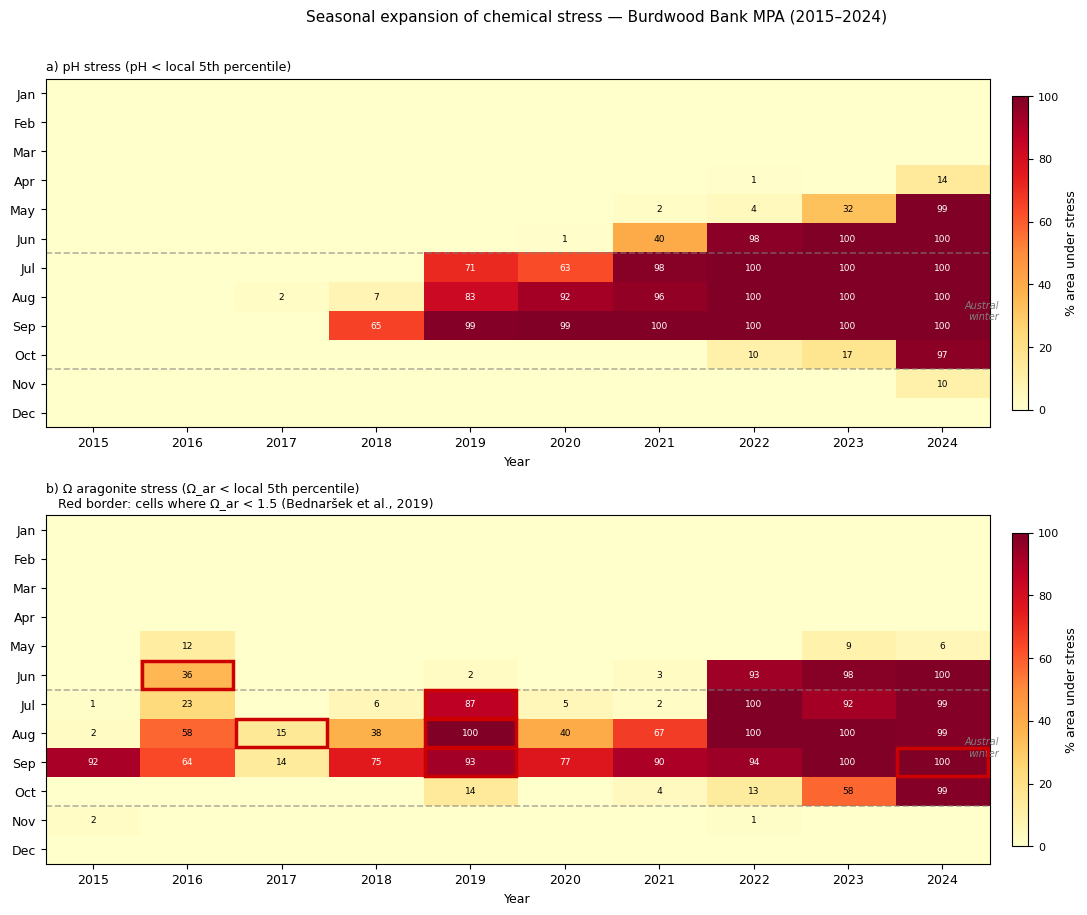

✅ Fig5_stress_heatmap.png guardada


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =============================================================================
# Heatmap % área en estrés por mes × año
# pH (percentil 5 local) y Ω_ar (percentil 5 local + borde donde < 1.5)
# =============================================================================

years  = list(range(2015, 2025))
months_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

# matrix_ph, matrix_ar_p05, matrix_ar_thresh ya calculadas

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

panels = [
    (axes[0], matrix_ph, None,
     "a) pH stress (pH < local 5th percentile)",
     "YlOrRd", 0, 100, "% area under stress"),
    (axes[1], matrix_ar_p05, matrix_ar_thresh,
     "b) Ω aragonite stress (Ω_ar < local 5th percentile)\n"
     "   Red border: cells where Ω_ar < 1.5 (Bednaršek et al., 2019)",
     "YlOrRd", 0, 100, "% area under stress"),
]

for ax, matrix, matrix_thresh, title, cmap, vmin, vmax, cbar_label in panels:

    im = ax.imshow(matrix, aspect="auto", cmap=cmap,
                   vmin=vmin, vmax=vmax, origin="upper")

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, orientation="vertical",
                        pad=0.02, shrink=0.9)
    cbar.set_label(cbar_label, fontsize=9)

    # Ejes
    ax.set_xticks(range(len(years)))
    ax.set_xticklabels(years, fontsize=9)
    ax.set_yticks(range(12))
    ax.set_yticklabels(months_labels, fontsize=9)

    # Líneas separando invierno austral (jul-sep = índices 6,7,8)
    ax.axhline(5.5, color="gray", lw=1.2, linestyle="--", alpha=0.6)
    ax.axhline(9.5, color="gray", lw=1.2, linestyle="--", alpha=0.6)

    # Anotación invierno austral
    ax.text(len(years) - 0.4, 7.5, "Austral\nwinter",
            fontsize=7, color="gray", va="center", ha="right",
            fontstyle="italic")

    # Valores en cada celda (solo si > 0)
    for i in range(12):
        for j in range(len(years)):
            val = matrix[i, j]
            if val > 0:
                color = "white" if val > 60 else "black"
                ax.text(j, i, f"{val:.0f}",
                        ha="center", va="center",
                        fontsize=6.5, color=color)

    # Bordes rojos donde Ω_ar < 1.5 (solo panel b)
    if matrix_thresh is not None:
        for i in range(12):
            for j in range(len(years)):
                if matrix_thresh[i, j] > 0:
                    rect = mpatches.FancyBboxPatch(
                        (j - 0.48, i - 0.48), 0.96, 0.96,
                        boxstyle="square,pad=0",
                        linewidth=2.5, edgecolor="#CC0000",
                        facecolor="none", zorder=5
                    )
                    ax.add_patch(rect)

    ax.set_title(title, fontsize=9, loc="left")
    ax.set_xlabel("Year", fontsize=9)

plt.suptitle(
    "Seasonal expansion of chemical stress — Burdwood Bank MPA (2015–2024)",
    fontsize=11, y=1.01
)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Fig5_stress_heatmap.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Fig5_stress_heatmap.png guardada")

### Fig p5 nueva para paper (heatmap)

Calculando matriz pH...
Calculando matriz Ω_ar (percentil 5)...
Calculando matriz Ω_ar (umbral 1.5)...
pH max: 100.0%
Ω_ar p05 max: 100.0%
Ω_ar <1.5 max: 6.5%


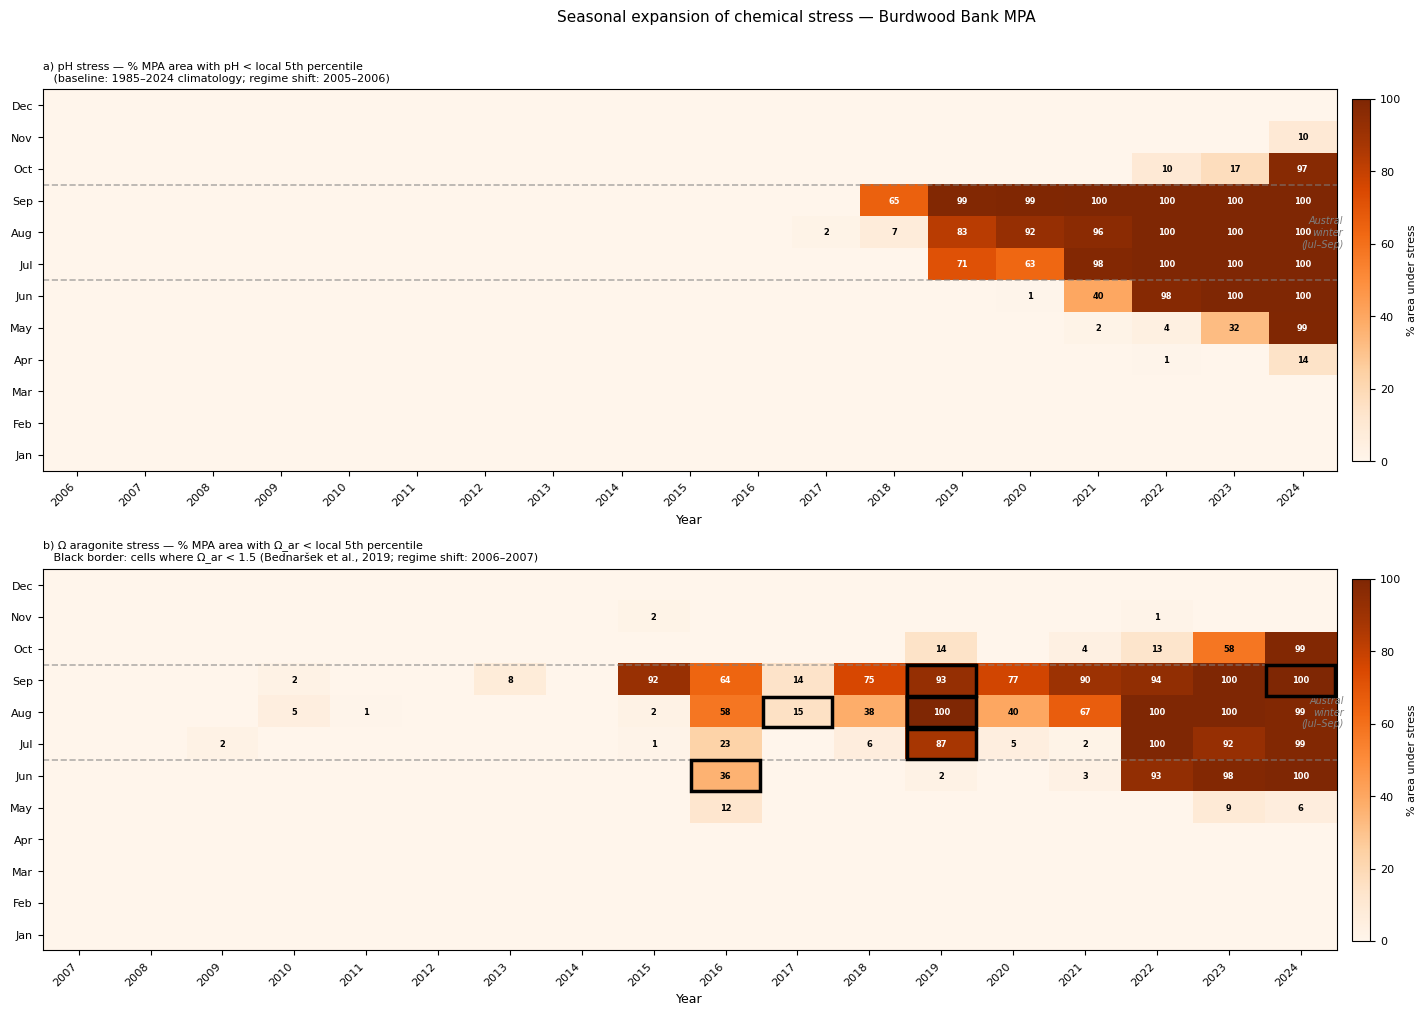

✅ Fig5_stress_heatmap.png guardada


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =============================================================================
# Heatmap % área en estrés por mes × año
# pH desde 2006 (cambio régimen), Ω_ar desde 2007
# Meses en orden ascendente (enero abajo, diciembre arriba)
# =============================================================================

months_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
})

# =============================================================================
# Calcular matrices
# =============================================================================

def compute_stress_matrix(da_bb, thresh_or_p05, years):
    """
    Calcula % área en estrés por mes × año.
    thresh_or_p05: DataArray (percentil 5 por píxel) o float (umbral absoluto)
    """
    matrix = np.zeros((12, len(years)))
    for j, year in enumerate(years):
        for i, month in enumerate(range(1, 13)):
            time_mask = (da_bb.time.dt.year == year) & \
                        (da_bb.time.dt.month == month)
            da_m = da_bb.sel(time=time_mask)
            if da_m.sizes["time"] > 0:
                if isinstance(thresh_or_p05, float):
                    stress = da_m < thresh_or_p05
                else:
                    stress = da_m < thresh_or_p05
                n_stress = stress.sum(dim=["latitude", "longitude"])
                n_valid  = (~da_m.isnull()).sum(dim=["latitude", "longitude"])
                val = float(100 * n_stress / n_valid)
                matrix[i, j] = val
    return matrix

years_ph = list(range(2006, 2025))
years_ar = list(range(2007, 2025))

print("Calculando matriz pH...")
matrix_ph = compute_stress_matrix(ph_bb, ph_p05, years_ph)

print("Calculando matriz Ω_ar (percentil 5)...")
matrix_ar_p05 = compute_stress_matrix(omega_ar_bb, omega_ar_p05, years_ar)

print("Calculando matriz Ω_ar (umbral 1.5)...")
matrix_ar_thresh = compute_stress_matrix(omega_ar_bb, 1.5, years_ar)

print(f"pH max: {matrix_ph.max():.1f}%")
print(f"Ω_ar p05 max: {matrix_ar_p05.max():.1f}%")
print(f"Ω_ar <1.5 max: {matrix_ar_thresh.max():.1f}%")

# =============================================================================
# Figura
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

panels = [
    (axes[0], matrix_ph,     None,              years_ph,
     "a) pH stress — % MPA area with pH < local 5th percentile\n"
     "   (baseline: 1985–2024 climatology; regime shift: 2005–2006)",
     0, 100),
    (axes[1], matrix_ar_p05, matrix_ar_thresh,  years_ar,
     "b) Ω aragonite stress — % MPA area with Ω_ar < local 5th percentile\n"
     "   Black border: cells where Ω_ar < 1.5 (Bednaršek et al., 2019; regime shift: 2006–2007)",
     0, 100),
]

for ax, matrix, matrix_thresh, years, title, vmin, vmax in panels:

    # Invertir para que enero quede abajo
    matrix_plot = matrix[::-1, :]

    im = ax.imshow(matrix_plot, aspect="auto", cmap="Oranges",
                   vmin=vmin, vmax=vmax, origin="upper")

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, orientation="vertical",
                        pad=0.01, shrink=0.95)
    cbar.set_label("% area under stress", fontsize=8)

    # Ejes
    ax.set_xticks(range(len(years)))
    ax.set_xticklabels(years, fontsize=8, rotation=45, ha="right")
    ax.set_yticks(range(12))
    # Invertido: diciembre arriba (índice 0), enero abajo (índice 11)
    ax.set_yticklabels(months_labels[::-1], fontsize=8)

    # Líneas invierno austral (jul=índice 5, sep=índice 3 en matriz invertida)
    # En matriz invertida: dic=0, nov=1, oct=2, sep=3, ago=4, jul=5, jun=6...
    ax.axhline(2.5, color="gray", lw=1.2, linestyle="--", alpha=0.6)  # entre sep y oct
    ax.axhline(5.5, color="gray", lw=1.2, linestyle="--", alpha=0.6)  # entre jun y jul

    # Anotación invierno
    ax.text(len(years) - 0.4, 4,
            "Austral\nwinter\n(Jul–Sep)",
            fontsize=7, color="gray", va="center", ha="right",
            fontstyle="italic")

    # Valores en cada celda si > 0
    for i in range(12):
        for j in range(len(years)):
            val = matrix_plot[i, j]
            if val > 0:
                color = "white" if val > 60 else "black"
                ax.text(j, i, f"{val:.0f}",
                        ha="center", va="center",
                        fontsize=6, color=color, fontweight="bold")

    # Bordes negros donde Ω_ar < 1.5
    if matrix_thresh is not None:
        matrix_thresh_plot = matrix_thresh[::-1, :]
        for i in range(12):
            for j in range(len(years)):
                if matrix_thresh_plot[i, j] > 0:
                    rect = mpatches.FancyBboxPatch(
                        (j - 0.48, i - 0.48), 0.96, 0.96,
                        boxstyle="square,pad=0",
                        linewidth=2.5, edgecolor="black",
                        facecolor="none", zorder=5
                    )
                    ax.add_patch(rect)

    ax.set_title(title, fontsize=8, loc="left")
    ax.set_xlabel("Year", fontsize=9)

plt.suptitle(
    "Seasonal expansion of chemical stress — Burdwood Bank MPA",
    fontsize=11, y=1.01
)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Fig5_stress_heatmap.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Fig5_stress_heatmap.png guardada")

Explicación del Panel a) — pH
2006–2016 (post-régimen temprano): prácticamente sin estrés. Solo un evento muy pequeño en agosto 2017 (2% del área). El océano ya cambió de régimen pero aún no hay condiciones de estrés extremo.
2018: empiezan los primeros eventos invernales significativos — agosto (7%) y septiembre (65%). El estrés todavía está concentrado en invierno estricto.
2019–2020: el estrés invernal se intensifica y alcanza casi el 100% del área en julio–septiembre. Aparece junio por primera vez.
2021: el estrés se expande hacia mayo (2%) y junio (40%) — el "invierno químico" empieza más temprano.
2022–2023: el estrés cubre prácticamente todo el año entre mayo y octubre. Ya no es solo invernal.
2024: el patrón más extremo — el estrés arranca en abril (14%) y dura hasta noviembre (10%). Son 8 meses consecutivos con estrés. El BB está en condiciones de estrés de pH la mayor parte del año.

Explicación del Panel b) — Ω_ar
El patrón es similar pero mucho más moderado:
2015–2016: estrés en mayo–septiembre, con el primer evento donde Ω_ar < 1.5 en junio 2016 (borde negro, 36% del área).
2017–2018: estrés concentrado en invierno, con un evento breve donde Ω_ar < 1.5 en agosto 2017 (borde negro, 15%).
2019: el año más crítico — estrés invernal intenso (87–100%) y tres meses consecutivos con Ω_ar < 1.5 (bordes negros en jul–sep).
2020–2022: estrés significativo en invierno pero sin cruzar el umbral de 1.5.
2023–2024: estrés muy intenso en invierno (92–100%) expandiéndose a junio y octubre, con un nuevo evento donde Ω_ar < 1.5 en septiembre 2024 (borde negro).

El mensaje principal de los dos paneles
El estrés químico en el BB no es solo más intenso con el tiempo — también dura más meses por año. Lo que en 2017–2018 era un fenómeno de 2 meses en invierno estricto, para 2024 es un fenómeno de 8 meses que abarca casi todo el año. Esta expansión estacional es uno de los resultados más novedosos del paper. 

In [36]:
# Percentil 5 por mes calendario (12 valores por píxel)
ph_p05_monthly = ph_bb.groupby("time.month").quantile(0.05)
omega_ar_p05_monthly = omega_ar_bb.groupby("time.month").quantile(0.05)

# Comparar con el percentil 5 global
print("pH — percentil 5:")
print(f"  Global (actual) : {float(ph_p05.mean()):.4f}")
print(f"  Mensual (nuevo) : {float(ph_p05_monthly.mean()):.4f}")
print(f"  Rango mensual   : {float(ph_p05_monthly.min()):.4f} – {float(ph_p05_monthly.max()):.4f}")

print("\nΩ_ar — percentil 5:")
print(f"  Global (actual) : {float(omega_ar_p05.mean()):.4f}")
print(f"  Mensual (nuevo) : {float(omega_ar_p05_monthly.mean()):.4f}")
print(f"  Rango mensual   : {float(omega_ar_p05_monthly.min()):.4f} – {float(omega_ar_p05_monthly.max()):.4f}")

C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fn

pH — percentil 5:
  Global (actual) : 8.0397
  Mensual (nuevo) : 8.0454
  Rango mensual   : 8.0194 – 8.0751

Ω_ar — percentil 5:
  Global (actual) : 1.6094
  Mensual (nuevo) : 1.6691
  Rango mensual   : 1.5076 – 1.8561


C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [37]:
# Test rápido: ¿cuántos meses tienen estrés con el nuevo umbral?
stress_ar_monthly = omega_ar_bb.groupby("time.month") < omega_ar_p05_monthly

for year in range(2015, 2020):
    for month in range(1, 13):
        time_mask = (omega_ar_bb.time.dt.year == year) & \
                    (omega_ar_bb.time.dt.month == month)
        ar_m = stress_ar_monthly.sel(time=time_mask)
        if ar_m.sizes["time"] > 0:
            pct = float(100 * ar_m.sum(dim=["latitude","longitude"]) / \
                  (~omega_ar_bb.sel(time=time_mask).isnull()).sum(dim=["latitude","longitude"]))
            if pct > 0:
                print(f"  {year}-{month:02d}: {pct:.1f}%")

  2015-10: 1.8%
  2015-11: 35.1%
  2015-12: 17.9%
  2016-01: 24.4%
  2016-02: 78.0%
  2016-03: 25.6%
  2016-04: 11.3%
  2016-05: 22.6%
  2016-06: 20.8%
  2016-07: 3.6%
  2016-08: 0.6%
  2016-09: 6.0%
  2017-08: 3.0%
  2017-09: 2.4%
  2018-10: 1.2%
  2018-11: 2.4%
  2019-03: 13.1%
  2019-04: 11.9%
  2019-07: 14.9%
  2019-08: 19.0%
  2019-09: 13.1%
  2019-10: 3.6%
  2019-11: 3.0%
  2019-12: 0.6%


In [39]:
# Para cada período y variable, estadísticas espaciales del mapa invernal
# Para cada período y variable, estadísticas espaciales del mapa invernal
for col in COLS:
    var = col["var"]
    print(f"\n{'='*50}")
    print(f"  {var.upper()} INVERNAL — estadísticas espaciales")
    print(f"{'='*50}")
    
    # Umbral correcto por variable
    if var == "ph":
        thresh_map = ph_p05          # percentil 5 por píxel
        thresh_label = "p05 local"
    else:
        thresh_map = omega_ar_p05    # percentil 5 por píxel
        thresh_label = "p05 local"
    
    for (y1, y2, label), (data, _) in zip(col["periods"], col["maps"]):
        data_masked = data.where(inside)
        
        mean_val = float(data_masked.mean())
        min_val  = float(data_masked.min())
        max_val  = float(data_masked.max())
        
        min_idx = data_masked.where(data_masked == data_masked.min(), drop=True)
        min_lat = float(min_idx.latitude.values[0])
        min_lon = float(min_idx.longitude.values[0])
        
        # % píxeles bajo percentil 5 local
        pct_below = float(100 * (data_masked < thresh_map).sum() /
                         (~data_masked.isnull()).sum())
        
        print(f"\n  {label.replace(chr(10),' ')}:")
        print(f"    Media       : {mean_val:.4f}")
        print(f"    Mín         : {min_val:.4f} @ ({min_lat:.2f}°S, {min_lon:.2f}°W)")
        print(f"    Máx         : {max_val:.4f}")
        print(f"    % < {thresh_label}: {pct_below:.1f}%")


  PH INVERNAL — estadísticas espaciales

  b) Pre-regime (1985–2005):
    Media       : 8.0801
    Mín         : 8.0770 @ (-55.62°S, -61.88°W)
    Máx         : 8.0823
    % < p05 local: 0.0%

  c) Transitional (2006–2016):
    Media       : 8.0557
    Mín         : 8.0524 @ (-55.38°S, -61.88°W)
    Máx         : 8.0581
    % < p05 local: 0.0%

  d) High-stress (2017–2024):
    Media       : 8.0351
    Mín         : 8.0294 @ (-54.38°S, -58.88°W)
    Máx         : 8.0387
    % < p05 local: 100.0%

  OMEGA_AR INVERNAL — estadísticas espaciales

  f) Pre-regime (1985–2006):
    Media       : 1.7427
    Mín         : 1.6941 @ (-55.62°S, -61.88°W)
    Máx         : 1.7669
    % < p05 local: 0.0%

  g) Transitional (2007–2016):
    Media       : 1.6498
    Mín         : 1.5889 @ (-55.62°S, -61.62°W)
    Máx         : 1.6749
    % < p05 local: 0.0%

  h) High-stress (2017–2024):
    Media       : 1.5935
    Mín         : 1.5381 @ (-55.88°S, -60.88°W)
    Máx         : 1.6223
    % < p05 loca

"En los mapas de pH, todos los píxeles muestran valores muy similares — no hay gradiente espacial visible. En los mapas de Ω_ar hay más diferencia entre píxeles, con valores más bajos consistentemente en el sur del área."

¿Por qué el pH más bajo está en el centro de BBI?
El BB es un plateau somero con mezcla vertical intensa y recirculación de agua sobre él. El centro de BBI (~54.4°S, -58.9°W) es la zona donde:

La batimetría es más somera → mayor mezcla vertical → más CO₂ desde capas profundas llega a superficie
Menor influencia de aguas oceánicas externas que podrían "diluir" la señal de acidificación
Mayor tiempo de residencia del agua → más tiempo para acumular CO₂


¿Por qué Ω_ar más bajo está en el sur (BBII)?
BBII es la zona de slope con profundidades hasta 4000m. Las aguas más profundas y frías que ascienden por el slope tienen:

Menor temperatura → mayor solubilidad de CO₂ → más ácidas
Mayor concentración de CO₂ acumulado por respiración en profundidad
Menor estado de saturación de carbonato naturalmente — las aguas profundas están más cerca de la subsaturación


Lo interesante de la diferencia entre variables
El hecho de que pH y Ω_ar muestren patrones espaciales distintos sugiere que los procesos que controlan cada variable son parcialmente independientes:

El pH superficial refleja principalmente el intercambio de CO₂ con la atmósfera + mezcla vertical en el plateau
El Ω_ar refleja más el aporte de aguas profundas con menor estado de saturación vía upwelling en el slope


Para la discusión (4.3 o 4.4)

"The distinct spatial patterns of pH and Ω_ar stress within the NBB-MPA suggest partially independent controlling mechanisms. The lowest winter pH values were consistently observed in the central BBI plateau, likely reflecting enhanced CO₂ accumulation in the well-mixed, semi-enclosed waters of the shallow bank. In contrast, minimum Ω_ar values were concentrated in the southern BBII slope zone, consistent with the influence of upwelled deep waters with naturally lower carbonate saturation states. These contrasting patterns highlight the importance of considering multiple carbonate system variables when assessing biological vulnerability within the MPA."